# Programmatic Viz of Results - GCEs detected per region

# Import Statements (libraries + Functions)

In [1]:
import scipy.stats as stats


In [2]:
import numpy as np
import pandas as pd
import vcf
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import pickle
import scipy.stats
import scipy.stats as stats

%matplotlib inline

In [3]:
from pathlib import Path

In [4]:
import ast

In [5]:
import screed
import mmh3

In [6]:
from Bio import SeqIO


In [7]:
import json

In [8]:
# https://bioframe.readthedocs.io/en/latest/guide-intervalops.html
import bioframe as bf
#import bioframe.vis

In [9]:
import subprocess

In [10]:
from pycirclize import Circos


In [11]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch


In [12]:
from matplotlib.ticker import FuncFormatter

# Function to convert base pairs to megabases
def bp_to_mb(x, pos):
    return f'{x * 1e-6:.1f}'

In [13]:
# Define matplotlib plot style from config file
plt.style.use('../mgm.v1.mplstyle')

In [14]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

#### Pandas Viewing Settings

In [15]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

# Import custom utils functions

In [16]:
%load_ext autoreload
%autoreload 2
    
from gcutils.general import Rv_dist, compute_Paralog_EdgeToEdge_Distance

from gcutils.eventtoparalogcomparison import genViz_RecombEvent_Vs_Paralogs_V3
from gcutils.eventtoparalogcomparison import process_and_visualize_event

from gcutils.eventtoparalogcomparison import getEventKmerMatchInfo_TopParalogMatches

# from gcutils.homologymapfuncs import label_HmMap_PAF_DF_ByOvrLapGenes, label_HmMap_Variants_DF_ByOvrLapGenes



### Import functions for plotting Gene Annotations + Results (GCEs + Epitopes, MutFreq, etc)

In [17]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

from gcutils.genomeviz_utils import plot_Anno_WiVariantCalls_2Panel, plot_Anno_with_empty_bottom

from gcutils.genomeviz_utils import add_cdseffect_legend, pack_intervals_greedy
from gcutils.genomeviz_utils import plot_multi_event_snp_packed_on_ax_V2, plot_Anno_with_GCE_V3

from gcutils.genomeviz_utils import plot_variants_for_isolates_simple
from gcutils.genomeviz_utils import plot_paralog_variants_on_ax
from gcutils.genomeviz_utils import plot_genome_annotation_on_ax

from gcutils.genomeviz_utils import plot_ParalogVars_Anno_with_GCE

from gcutils.genomeviz_utils import overlay_gc_event_highlights_on_variants

from gcutils.genomeviz_utils import viz_region_Tree_Variants_Anno_ParalogVariants, viz_region_Tree_Variants_Anno   


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Import functions related to phylogeny/tree viz

In [18]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
    
from gcutils.gubbinsfuncs import get_BranchLengths_and_DescendantCounts_FromTree
from gcutils.gubbinsfuncs import subset_EventsDF_ForGenes

from gcutils.gubbinsfuncs import annotate_tree_with_lineages, infer_InternalNode_Lineages

from gcutils.treeviz_mpl import mpl_plot_tree

from gcutils.treeviz_ete_utils import subset_tree_by_leaf_ids, subset_ETE_Tree
from gcutils.treeviz_ete_utils import style_ETE3_Tree_ByMtbLineage_V1

from gcutils.treeviz_ete_utils import style_single_node_in_tree
from gcutils.treeviz_ete_utils import subset_ETE_Tree_Style_GCEChildNode 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Define Functions

In [19]:
import re
import pandas as pd
import numpy as np

# reuse your existing regex
CS_OP_RE = re.compile(r'([:=*+-])(\d+|[A-Za-z]+)')

def count_substitutions_in_cs(cs: str) -> int:
    """
    Count the number of substitution events (*xy) in a minimap2 cs tag.

    Parameters
    ----------
    cs : str
        A single cs tag string (e.g. ':6-ata:10+gtc:4*at:3').

    Returns
    -------
    int
        Number of substitutions detected in this cs string.
    """
    if cs is None or (isinstance(cs, float) and pd.isna(cs)):
        return 0

    n_sub = 0
    for op, arg in CS_OP_RE.findall(cs):
        if op == '*':
            # arg is two bases: ref, query
            ref_base = arg[0]
            alt_base = arg[1]
            # mirror your variant logic: skip ambiguous Ns
            if ref_base.lower() != "n" and alt_base.lower() != "n":
                n_sub += 1

    return n_sub


In [20]:

def calculate_gc_content_perwindow(genome_seq, df,
                                   start_col = "Target_Start",
                                   end_col   = "Target_End"):
    """
    Compute GC content for each genomic window in the DataFrame.
    
    Parameters:
    - genome (str): The full genome sequence as a string.
    - df (pd.DataFrame): DataFrame containing "Target_Start" and "Target_End" columns.
    
    Returns:
    - pd.DataFrame: Updated DataFrame with a new column "GC_Content".
    """
    gc_contents = []
    
    for _, row in df.iterrows():
        start = int(row[start_col]) - 1  # Convert to 0-based indexing
        end = int(row[end_col])
        
        # Extract sequence from genome string
        subseq = genome_seq[start:end]
        
        # Calculate GC content
        gc_count = subseq.count('G') + subseq.count('C')
        total_bases = len(subseq)
        gc_content = (gc_count / total_bases) * 100 if total_bases > 0 else None
        
        gc_contents.append(gc_content)

    # Add results to DataFrame
    df["GC_Content"] = gc_contents
    df["GC_Content"] = df["GC_Content"].astype(float)

    return df



# Define Functions - GC Event Processing and Org

In [21]:
from typing import Dict, Any
from ete3 import Tree
import pandas as pd

def build_GCE_event_context_dict(
    tree: Tree,
    i_pGCE_DF: pd.DataFrame,
    i_GubSNPs_All_DF: pd.DataFrame,
) -> Dict[Any, Dict[str, Any]]:
    """
    Pre-compute and cache useful context for each GCE EventID.

    Returns
    -------
    event_context_dict : dict
        Keys are EventID values from i_pGCE_DF["EventID"].
        Each value is a dict with:
          - "pGCE_Row_DF"             : DataFrame subset of i_pGCE_DF for this EventID
          - "Parent_Node"             : parent node name (string)
          - "Child_Node"              : child node name where event is inferred
          - "SubTree_At_Child"        : ete3.Tree subtree rooted at Child_Node
          - "SubTree_At_Parent"       : ete3.Tree subtree rooted at Parent_Node
          - "GubSNPs_TargetGCE_DF"    : subset of i_GubSNPs_All_DF for this EventID
          - "GCE_SNP_Pos_0based"      : list of positions (Pos_0based) for this event
          - "ChildSubtree_LeafIDs"    : list of leaf (SampleID) names under Child subtree
          - "ParentSubtree_LeafIDs"   : list of leaf (SampleID) names under Parent subtree
    """

    event_context_dict: Dict[Any, Dict[str, Any]] = {}

    for i_EventID in i_pGCE_DF["EventID"].unique():
        # 1) Subset pGCE rows for this event
        i_pGCE_Row_DF = i_pGCE_DF.loc[i_pGCE_DF["EventID"] == i_EventID].copy()

        if i_pGCE_Row_DF.empty:
            # Shouldn't happen if EventID comes from i_pGCE_DF["EventID"].unique(),
            # but we guard anyway.
            continue

        # For parent/child node names, we assume they are consistent per EventID
        i_row = i_pGCE_Row_DF.iloc[0]
        i_ParentNode_Name = i_row["Parent_Node"]
        i_ChildNode_Name  = i_row["Child_Node"]

        # 2) Subtrees at child and parent
        i_SubTree_AtChildNode  = subset_ETE_Tree(i_ChildNode_Name, tree)
        i_SubTree_AtParentNode = subset_ETE_Tree(i_ParentNode_Name, tree)

        i_SubTree_AtParentNode_VizGCE = subset_ETE_Tree_Style_GCEChildNode(i_ParentNode_Name, i_ChildNode_Name, tree)


        # Style the child node of the GC Event in the entire tree
        i_Full_Tree_Highlight_EventBranch = style_single_node_in_tree(tree, i_ChildNode_Name)


        
        # 3) SNPs associated with this event from GubSNPs
        i_GubSNPs_TargetGCE_DF = i_GubSNPs_All_DF.loc[
            i_GubSNPs_All_DF["EventID"] == i_EventID
        ].copy()

        i_GCE_SNP_Pos_0based = []
        if not i_GubSNPs_TargetGCE_DF.empty:
            i_GCE_SNP_Pos_0based = list(i_GubSNPs_TargetGCE_DF["Pos_0based"].values)

        # 4) Leaf IDs under child and parent subtrees
        ChildSubtree_LeafIDs = [leaf.name for leaf in i_SubTree_AtChildNode.iter_leaves()]
        ParentSubtree_LeafIDs = [leaf.name for leaf in i_SubTree_AtParentNode.iter_leaves()]


        # https://stackoverflow.com/questions/3428536/python-list-subtraction-operation 
        NotAffected_LeafNames = [item for item in ParentSubtree_LeafIDs if item not in ChildSubtree_LeafIDs]

        
        # 5) Assemble context dict for this event
        event_context = {
            "pGCE_Row_DF": i_pGCE_Row_DF,
            "E_Parent_Node": i_ParentNode_Name,
            "E_Child_Node": i_ChildNode_Name,
            "E_Child_SubTree": i_SubTree_AtChildNode,
            "E_Parent_SubTree": i_SubTree_AtParentNode,
            "E_Parent_SubTree_ColorChildNode": i_SubTree_AtParentNode_VizGCE,
            "E_LeafIDs_CladeWith_Event": ChildSubtree_LeafIDs,
            "E_LeafIDs_CladeWithout_Event": NotAffected_LeafNames,
            "E_LeafIDs_OfParentSubtree": ParentSubtree_LeafIDs,
            "E_ASR_SNP_DF": i_GubSNPs_TargetGCE_DF,
            "E_SNP_Pos_0based": i_GCE_SNP_Pos_0based,
            "Tree_With_GCE_ChildNode_Highlight": i_Full_Tree_Highlight_EventBranch,
        }

        event_context_dict[i_EventID] = event_context

    return event_context_dict


## ETE3 Settings & Parameters Setup

### Link to ETE3 documentation for tree layout style
 http://etetoolkit.org/docs/latest/tutorial/tutorial_drawing.html#interactive-visualization-of-trees

In [22]:

import ete3 as ETE

from ete3 import Tree

# https://github.com/ipython/ipython/issues/10627
import os
os.environ['QT_QPA_PLATFORM']='offscreen'

In [23]:
Mtb_LinToColor_Dict = {"lineage1": "#DF83AC",
                      "lineage2": "#7098CB",
                      "lineage3": "#815D9F",
                      "lineage4": "#E76956",
                      "lineage5": "#B67548",
                      "lineage6": "#6AB79E",
                      "lineage8": "#E4515B", 
                      "None": "black",}


In [24]:

ts_vt_NoScale = ETE.TreeStyle()
ts_vt_NoScale.show_leaf_name = False
ts_vt_NoScale.show_branch_length = False
ts_vt_NoScale.show_branch_support = False
ts_vt_NoScale.show_scale = False #True
ts_vt_NoScale.branch_vertical_margin = 2
ts_vt_NoScale.rotation = 90

ts_hz_NoScale = ETE.TreeStyle()
ts_hz_NoScale.show_leaf_name = False
ts_hz_NoScale.show_branch_length = False
ts_hz_NoScale.show_branch_support = False
ts_hz_NoScale.show_scale = False #True
ts_hz_NoScale.branch_vertical_margin = 2
ts_hz_NoScale.rotation = 0

ts_ColLin = ETE.TreeStyle()
ts_ColLin.show_leaf_name = False
ts_ColLin.show_branch_length = False
ts_ColLin.show_branch_support = False
ts_ColLin.show_scale = True #True
ts_ColLin.branch_vertical_margin = 2
#ts_ColLin.layout_fn = Mtb_ColorBranchByLineage_Layout
ts_ColLin.rotation = 90

ts_ColLin_circ = ETE.TreeStyle()
ts_ColLin_circ.mode = "c" # draw tree in circular mode
ts_ColLin_circ.arc_start = 0 #-180 # 0 degrees = 3 o'clock
ts_ColLin_circ.arc_span = 180
ts_ColLin_circ.show_leaf_name = False
ts_ColLin_circ.show_branch_length = False
ts_ColLin_circ.show_branch_support = False
ts_ColLin_circ.show_scale = False #True
ts_ColLin_circ.branch_vertical_margin = 2
#ts_ColLin_circ.layout_fn = Mtb_ColorBranchByLineage_Layout

ts_ColLin_FullCirc = ETE.TreeStyle()
ts_ColLin_FullCirc.mode = "c" # draw tree in circular mode
ts_ColLin_FullCirc.arc_start = -90 #-180 # 0 degrees = 3 o'clock
ts_ColLin_FullCirc.arc_span = 355
ts_ColLin_FullCirc.show_leaf_name = False
ts_ColLin_FullCirc.show_branch_length = False
ts_ColLin_FullCirc.show_branch_support = False
ts_ColLin_FullCirc.show_scale = False #True
ts_ColLin_FullCirc.branch_vertical_margin = 2
# ts_ColLin_FullCirc.rotation = 90


# Pre-process Data for Genome Viz w/ `DNA-Features-Viewer`

### Import/setup DNA Features Viewer (For plotting H37rv genome annotations)

In [25]:
from dna_features_viewer import GraphicFeature, GraphicRecord, CircularGraphicRecord, BiopythonTranslator
from Bio import SeqIO
from Bio.SeqFeature import SeqFeature, FeatureLocation


In [26]:
BiopythonTranslator.label_fields = ['gene', 'label', 'source', 'locus_tag', 'note', 'gene', 'product']
BiopythonTranslator.ignored_features_types = ["source", "gene"]
BiopythonTranslator.default_feature_color = "lightgrey"

## Create H37Rv Genome Record + Results Features Objects

In [27]:
H37rv_Ref_GBK_PATH = "/n/data1/hms/dbmi/farhat/mm774/References/GCF_000195955.2_ASM19595v2_genomic.gbk"

In [28]:
records = list(SeqIO.parse(H37rv_Ref_GBK_PATH, "genbank"))
print(len(records))
Mtb_H37rv_SeqIO_Record = records[0]

CDS_Features = []

for feature in Mtb_H37rv_SeqIO_Record.features:
    if feature.type == "CDS":
        CDS_Features.append(feature) 
        # if "gene" in feature.qualifiers.keys():
        #     if feature.qualifiers["locus_tag"] == ['Rv1196']:
        #         print(feature)
        #         print()

# --- Manually add esxM (Rv1792) ---

# esxM gene info
esxM_start = 2030346  # GenBank is 0-based, so subtract 1 from 1-based start
esxM_end = 2030643    # end is exclusive in Biopython
esxM_seq = (
    "atggcctcacgttttatgacggatccgcatgcgatgcgggacatggcgggccgttttgaggtgcacgcccagacggtggaggacgaggctcgccggatgtgggcgtccgcgcaaaacatttccggtgcgggctggagtggcatggccgaggcgacctcgctagacaccatgacctagatgaatcaggcgtttcgcaacatcgtgaacatgctgcacggggtgcgtgacgggctggttcgcgacgccaacaactacgaacagcaagagcaggcctcccagcagatcctgagcagctag"
)

# Create the SeqFeature object
esxM_feature = SeqFeature(
    location=FeatureLocation(esxM_start, esxM_end, strand=1),
    type="CDS",
    qualifiers={
        "locus_tag": ["Rv1792"],
        "gene": ["esxM"],
        "product": ["esxM hypothetical protein"],
        "translation": [
            "MASRFMTDPHAMRDMAGRFEVHAQTVEDEARRMWASAQNISGAGWSGMAEATSLDTMTMNQAFRNIVNMLHGVRDGLVRDANNYEQQEQASQQILSS"
        ]
    }
)

# Append to the list of CDS features
CDS_Features.append(esxM_feature)

Mtb_H37rv_SeqIO_Record.features = CDS_Features

Mtb_H37rv_Graphic_Record = BiopythonTranslator().translate_record(Mtb_H37rv_SeqIO_Record)
Mtb_H37rv_Graphic_Record.feature_level_height = 0

1


# Parse `Mtb151CI` Isolate Metadata

In [29]:
Repo_DataDir = "../../Data"
InputAsmPath_Dir = f"{Repo_DataDir}/231121.InputAsmTSVs.MtbSetV3.151CI"

MtbSetV3_151CI_InputAsmPATHs_TSV = f"{InputAsmPath_Dir}/231121.MtbSetV3.151CI.HybridAndSRAsm.FAPATHs.V1.tsv"
MtbSetV3_151CI_AsmSumm_TSV = f"{InputAsmPath_Dir}/231121.MtbSetV3.151CI.HybridAsm.AsmSummary.V2.tsv"


### Reading in "WGA151CI_AsmSummary_DF"

In [30]:
WGA151CI_AsmSummary_DF = pd.read_csv(MtbSetV3_151CI_AsmSumm_TSV, sep = "\t")

SampleIDs_151CI_SOI = list( WGA151CI_AsmSummary_DF["SampleID"].values )
WGA151CI_SampleIDs = SampleIDs_151CI_SOI
WGA151CI_AsmSummary_DF.shape


(151, 7)

#### Create SampleID Mapping Dicts

In [31]:
WGA151CI_ID_To_PrimLineage_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'PrimaryLineage']].values)
WGA151CI_ID_To_SubLineage_Dict = dict( WGA151CI_AsmSummary_DF[["SampleID", "Lineage"]].values)
WGA151CI_ID_To_Dataset_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'Dataset_Tag']].values)  

SampleID_To_PrimLineage_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'PrimaryLineage']].values)
SampleID_To_SubLineage_Dict = dict( WGA151CI_AsmSummary_DF[["SampleID", "Lineage"]].values)
SampleID_To_Dataset_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'Dataset_Tag']].values)  


In [32]:
WGA151CI_OrderOfSampleIDs_Phylo = ['N0153', 'N0072', 'mada_2-46', 'mada_1-44', 'mada_107', 'mada_1-1', 'mada_1-51',
                          'mada_1-39', 'mada_1-36', 'mada_117', 'mada_122', 'mada_118', 'mada_1-10', 'R27252',
                          'R23887', 'TB3091', '9050-05', '3003-06', '702-06', '696-05', '8651-04', 'TB3396',
                          '4549-04', 'TB1612', 'TB2780', 'TB3368', 'TB1236', 'TB2659', '8129-04', 'R30215',
                          'R25048', 'TB2512', 'TB2981', 'TB2995', 'TB3113', '706-05', 'R30078', 'R28012',
                          'R27657', 'R30234', 'R31095', 'R28703', 'R24120', 'R36431', 'R29816', 'S0070-08',
                          'N0155', 'N0145', 'R29598', 'R24100', 'S0107-01', 'R28581', 'S0256-08', 'S0085-01',
                          'S0089-01', 'mada_1-11', 'M0003941_3', 'mada_115', 'mada_2-42', 'R37765', '18_0621851',
                          'R22601', 'R27937', 'R18040', 'R18043', 'R27725', 'R26791', 'R20574', 'R20260', 'R21408',
                          'R23146', 'R28980', 'R32929', 'R26778', 'R30420', 'R21893', 'QC-9', 'QC-5', 'QC-3', 'N0004',
                          'mada_1-30', 'N0054', 'N1274', '01_R1134', 'TB2968', 'mada_1-53', 'mada_2-53', 'mada_1-50',
                          'mada_2-1', 'R23571', 'mada_123', 'mada_1-12', 'mada_1-15', 'mada_128', 'mada_1-38', 'TB3054',
                          'mada_126', 'mada_120', 'TB4620', 'M0016737_0', 'M0016395_7', 'R15311', 'TB2661', 'TB3386',
                          'TB3162', '02_R1179', 'M0010874_7', 'QC-7', 'QC-6', 'QC-1', '01_R1430', 'M0011368_9',
                          '02_R1896', 'mada_2-25', 'TB3237', 'mada_103', 'mada_112', 'mada_124', 'S0123-01', 'S0262-02',
                          'TB3251', 'M0017522_5', 'R30396', 'R20896', 'mada_1-32', 'S0106-01', 'R21839', 'R21363', 'R21770',
                          'MT_0080', 'mada_102', 'TB3334', 'M0014888_3', 'mada_151', 'TB3169', 'mada_105', 'QC-8', 'QC-10',
                          'QC-4', 'mada_129', 'mada_139', '02_R1708', '02_R0894', 'mada_2-31', 'mada_1-41', 'N1272', 'N1176',
                          'N1202', 'N0091', 'N1177', 'RW-TB008']


# Parse all individual variants per genome annotated by CDS effect (`WGA-151CI`)

In [33]:
Mtb151_AllVar_Dir = "../../Data/241030.Mtb151CI.AllVariants.Anno.V1/"

Mtb151_AllVar_TSVGZ              = f"{Mtb151_AllVar_Dir}/Mtb.151CI.AllVariants.V1.tsv.gz"
Mtb151_AllVar_WiCDSAnno_TSVGZ    = f"{Mtb151_AllVar_Dir}/Mtb.151CI.AllVariants.WiCDSAnno.V1.tsv.gz"
Mtb151_SNPs_WiInterSNPDist_TSVGZ = f"{Mtb151_AllVar_Dir}/Mtb.151CI.AllSNPs.WiInterSNPDists.V1.tsv"


In [34]:

Mtb151CI_AllAsm_AllVar_DF = pd.read_csv(Mtb151_AllVar_WiCDSAnno_TSVGZ, sep="\t")

# WGA151_AllVar_DF = Mtb151CI_AllAsm_AllVar_DF
AllAsm_AllVar_DF = Mtb151CI_AllAsm_AllVar_DF
AllAsm_AllVar_DF.shape

(260869, 20)

In [35]:
AllAsm_AllVar_DF["SampleID"].nunique()

151

# Parse HHRs tested for Enrichment of "Paralog-Matching" SNPs

In [36]:
HHR_TestForParalogSNPs_TSV = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/Analysis/4_Mtb_HHR_MutAttributes_V3/HHR.TestedForParalogSNPS.V1.tsv"

HHR_SNP_Sig_DF  = pd.read_csv(HHR_TestForParalogSNPs_TSV,
                              sep = "\t")

HHR_SNP_Sig_DF["Num_Overlap_Genes"] = HHR_SNP_Sig_DF["Overlap_Genes"].str.split(",").apply(len)

HHR_SNP_Sig_DF.shape

(21, 32)

In [37]:
HHR_SNP_Sig_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,NPossible_SNPs_Total,NPossible_ParalogSNPs,NObserved_SNPs_Total,NObserved_SNPs_MatchParalogSNP,p_value,log_p_value,neglog_p_value,NExpected_MatchParalogSNP,p_corr,neglog_p_corr,NucDivHotspot_Ovrlap,FoldEnrichment,LogFoldEnrichment,Log2FoldEnrichment,AbsEnrichment,SizeFactor,Num_Overlap_Genes
0,34,NC_000962.3,889019,891461,890240.0,2442,"Rv0795,Rv0796,Rv0797",3,15,1,0,34,PR_HmRegion_034,2,PR_Set_24,7326,1,29,7,0.0,500.0,500.0,0.003959,1.000000e-40,500.0,0,1768.344828,3.247567,10.788184,6.996041,0.109375,3
1,123,NC_000962.3,2828493,2829936,2829214.5,1443,Rv2512c,1,5,4,0,123,PR_HmRegion_123,0,PR_Set_30,4329,4,41,14,0.0,500.0,500.0,0.037884,1.000000e-40,500.0,0,369.548780,2.567672,8.529621,13.962116,0.218750,1
2,131,NC_000962.3,2982934,2983854,2983394.0,920,"Rv2665,Rv2666",1,5,5,0,131,PR_HmRegion_131,0,PR_Set_30,2760,3,25,6,0.0,500.0,500.0,0.027174,1.000000e-40,500.0,0,220.800000,2.343999,7.786596,5.972826,0.093750,2
3,55,NC_000962.3,1341295,1342730,1342012.5,1435,Rv1199c,1,5,4,0,55,PR_HmRegion_055,0,PR_Set_30,4305,4,38,7,0.0,500.0,500.0,0.035308,1.000000e-40,500.0,1,198.256579,2.297228,7.631225,6.964692,0.109375,1
4,157,NC_000962.3,3381311,3382749,3382030.0,1438,Rv3023c,1,5,3,0,157,PR_HmRegion_157,0,PR_Set_30,4314,3,45,4,0.0,500.0,500.0,0.031293,1.000000e-40,500.0,0,127.822222,2.106606,6.997995,3.968707,0.062500,1


# Import/parse processed H37rv genome annotations

In [38]:
RepoRef_Dir = "../../References"

AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir = f"{RepoRef_Dir}/201027_H37rv_AnnotatedGenes_And_IntergenicRegions"
#H37Rv_GenomeAnnotations_Genes_TSV = f"{AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir}/H37Rv_GenomeAnnotations.Genes.tsv"
H37Rv_GenomeAnnotations_Genes_V2_TSV = f"{AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir}/H37Rv_GenomeAnnotations.Genes.V2.tsv"

## H37Rv Gene Annotations TSV
H37Rv_GenomeAnno_Genes_DF = pd.read_csv(H37Rv_GenomeAnnotations_Genes_V2_TSV, sep = "\t")
H37Rv_GeneInfo_Subset_DF = H37Rv_GenomeAnno_Genes_DF[["H37rv_GeneID", "Symbol", "Feature", "Functional_Category", "Is_Pseudogene", "Product", "PEandPPE_Subfamily", "ExcludedGroup_Category"]]

RvID_To_Symbol_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['H37rv_GeneID', 'Symbol']].values)
Symbol_To_RvID_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['Symbol', 'H37rv_GeneID']].values)
Symbol_To_FuncCat_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['Symbol', 'Functional_Category']].values)

ESX_Genes_List_TSV = f"{RepoRef_Dir}/190927_H37rv_ListOf_ESXgenes.tsv"
Esx_Genes_DF = pd.read_csv(ESX_Genes_List_TSV, sep = '\t')

In [39]:
H37Rv_GenomeAnno_Genes_DF.head(1)

,Chrom,Start,End,Strand,H37rv_GeneID,Symbol,Feature,Functional_Category,Is_Pseudogene,Product,PEandPPE_Subfamily,ExcludedGroup_Category,Gene_Cat_V2
0,NC_000962.3,0,1524,+,Rv0001,dnaA,CDS,information pathways,No,Chromosomal replication initiator protein DnaA,NaN,NotExcluded,information pathways


### Define paths to H37Rv genome masking schemes

In [40]:
RepoRef_Dir = "../../References"

MaskingSchemes_Dir = f"{RepoRef_Dir}/Mtb_H37Rv_MaskingSchemes"
PLC_Scheme_BED = f"{MaskingSchemes_Dir}/201027_Mtb_H37rv_pLC_Regions_CoscollaExcludedGenes.bed"


### Define relevant H37Rv gene lists for analysis (PE/PPE, Esx, 13E12 gene)

In [41]:
ListOf_Esx_Symbols = list(Esx_Genes_DF["symbol"].values)
ListOf_Esx_RvIDs = list(Esx_Genes_DF["gene_id"].values)

In [42]:
listOf_PEPPE_Symbols = list( H37Rv_GenomeAnno_Genes_DF.query(" Functional_Category == 'PE/PPE' ")["Symbol"].values )
listOf_PEPPE_RvIDs = list( H37Rv_GenomeAnno_Genes_DF.query(" Functional_Category == 'PE/PPE' ")["H37rv_GeneID"].values )

In [43]:
listOf_13E12_Region_RvIDs = ["Rv0094c", "Rv0095c", "Rv0393", "Rv1572c", "Rv1572c", "Rv1128c", "Rv1148c", "Rv1587c", "Rv1588c", "Rv1702c", "Rv1945", "Rv2100", "Rv3466", "Rv3467"]  


# Parse H37Rv Reference sequences (Genome, Genes, Proteins)

## Parse H37Rv genome sequence (DNA)

In [44]:
from Bio import SeqIO


In [45]:
H37rv_Ref_GBK_PATH = "/n/data1/hms/dbmi/farhat/mm774/References/GCF_000195955.2_ASM19595v2_genomic.gbk"
H37Rv_FA = "/n/data1/hms/dbmi/farhat/mm774/References/GCF_000195955.2_ASM19595v2_genomic.fasta"

H37Rv_Seq = SeqIO.read(H37Rv_FA, "fasta").seq
len(H37Rv_Seq)

4411532

## Parse H37Rv Protein (AA) and gene (DNA) sequences

In [46]:
O2_RefDir = "/n/data1/hms/dbmi/farhat/mm774/References"

MycoBrowser_RefFiles_Dir = f"{O2_RefDir}/190619_Mycobrowser_H37rv_ReferenceFiles"

H37Rv_Proteins_MycoBro_FAA = f"{MycoBrowser_RefFiles_Dir}/Mycobacterium_tuberculosis_H37Rv_proteins_v3_TrimmedHeader.fasta"
H37Rv_Proteins_MycoBro_FAA = f"{MycoBrowser_RefFiles_Dir}/Mycobacterium_tuberculosis_H37Rv_proteins_v3_TrimmedHeader.esxM_Added.fasta"
H37Rv_Proteins_NCBI_FAA = f"{MycoBrowser_RefFiles_Dir}/Mycobacterium_tuberculosis_H37Rv_proteins_v3_TrimmedHeader.fasta"
H37RV_Genes_FA = f"{MycoBrowser_RefFiles_Dir}/Mycobacterium_tuberculosis_H37Rv_genes_v3.fasta"



H37Rv_FAA_PATH = f"{O2_RefDir}/GCF_000195955.2_ASM19595v2_proteins.faa"
H37Rv_FAA_PATH = f"{O2_RefDir}/GCF_000195955.2_ASM19595v2_proteins.esxM_Added.faa"
H37Rv_GBK_PATH = f"{O2_RefDir}/GCF_000195955.2_ASM19595v2_genomic.gbk"


In [47]:
!ls -1 $MycoBrowser_RefFiles_Dir

Mycobacterium_tuberculosis_H37Rv_genes_v3.fasta
Mycobacterium_tuberculosis_H37Rv_genome_v3.fasta
Mycobacterium_tuberculosis_H37Rv_genome_v3.fasta.fai
Mycobacterium_tuberculosis_H37Rv_gff_v3.gff
Mycobacterium_tuberculosis_H37Rv_gff_v3.REP13E12_Regions.gff
Mycobacterium_tuberculosis_H37Rv_proteins_v3.fasta
Mycobacterium_tuberculosis_H37Rv_proteins_v3_TrimmedHeader.esxM_Added.fasta
Mycobacterium_tuberculosis_H37Rv_proteins_v3_TrimmedHeader.fasta
Mycobacterium_tuberculosis_H37Rv_txt_v3_PEPPE_subfamilies.txt
Mycobacterium_tuberculosis_H37Rv_txt_v3.txt.tsv


### Parse MycoBrowser Protein Seq Ref

In [48]:
dictOf_H37Rv_MycoBrow_ProtSeq = {}

for index, record in tqdm(enumerate(SeqIO.parse(H37Rv_Proteins_MycoBro_FAA, "fasta"))):
    ShortID = record.name
    
    dictOf_H37Rv_MycoBrow_ProtSeq[ShortID] = record.seq


4091it [00:00, 104926.21it/s]


### Parse MycoBrowser Gene Seq Ref

In [49]:
dictOf_H37Rv_MycoBrow_Gene_Seq = {}

for index, record in tqdm(enumerate(SeqIO.parse(H37RV_Genes_FA, "fasta"))):

    ShortID = record.name.split("|")[0]
    dictOf_H37Rv_MycoBrow_Gene_Seq[ShortID] = record.seq


4187it [00:00, 60363.91it/s]


In [50]:
list(dictOf_H37Rv_MycoBrow_Gene_Seq.keys())[:2]

['Rv3728', 'Rv3729']

### Parse NCBI Protein Seq Ref

In [51]:
dictOf_H37Rv_ProtSeq = {}
dictOf_H37Rv_ProtRecord = {}

for index, record in tqdm(enumerate(SeqIO.parse(H37Rv_FAA_PATH, "fasta"))):
    Rec_Description = record.description
    dict_Attr = {}
    for i in Rec_Description.split(" "):
        ###Just looking for line with " " character (as key = value)
        if "=" in i:
            key = i.strip().split("=")[0].strip('"').strip('[')
            value = i.strip().split("=")[1].strip('"').strip(']')
            ###Put them in a dictionnary
            dict_Attr[key]=value
    
    ShortID = dict_Attr["locus_tag"]
    dictOf_H37Rv_ProtSeq[ShortID] = record.seq
    dictOf_H37Rv_ProtRecord[ShortID] = record


3907it [00:00, 12271.84it/s]


In [52]:
#dictOf_H37Rv_ProtSeq["Rv1196"]

In [53]:
#dictOf_H37Rv_ProtSeq["Rv1196"] == dictOf_H37Rv_MycoBrow_ProtSeq["Rv1196"]

In [54]:
dictOf_H37Rv_ProtSeq["Rv1792"]

Seq('MASRFMTDPHAMRDMAGRFEVHAQTVEDEARRMWASAQNISGAGWSGMAEATSLDTMT')

In [55]:
dictOf_H37Rv_MycoBrow_ProtSeq["Rv1792"]

Seq('MASRFMTDPHAMRDMAGRFEVHAQTVEDEARRMWASAQNISGAGWSGMAEATSLDTMT')

# Parse in H37Rv Homology-Map Results (k19w19)

### Define all HmMap file paths

In [56]:
Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V9"

H37_Rv_MM2_HomologyMapping_Dir = f"{Main_Project_Dir}/250901.H37Rv.HomologyMapping.k19w19.ProcessedData.V2"

# Define paths to output TSVS

### Homologous regions (MERGED)
RvHmMap_Merged_ParaRegions_TSV  = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.MergedRegions.ParalogousRegions.k19w19.tsv"
RvHmMap_Merged_LocalRepeats_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.MergedRegions.LocalRepeats.k19w19.tsv"

### Homology map (pairwise alignments)
RvHmMap_Aln_All_TSV           = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.All.tsv"
RvHmMap_Aln_PRs_NoOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.NoOverlap.tsv"
RvHmMap_Aln_LRs_WiOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.WiOverlap.tsv"

RvHmMap_Aln_PRs_NoOverlap_Clustered_TSV     = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.NoOverlap.Clustered.tsv"
RvHmMap_Aln_LRs_WiOverlap_Clustered_TSV     = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.OnlyOverlap.Clustered.tsv"

### Variants from the homology map alignments
RvHmMap_Var_TSV      = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.tsv"
RvHmMap_Var_SNPs_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.snps.tsv"



### Variants from the homology map alignments (For each pairwise alignment between PRs)
RvHmMap_Var_PerAln_TSV      = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.ParalogousRegions.PerAln.tsv"
RvHmMap_Var_PerAln_SNPs_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.ParalogousRegions.PerAln.snps.tsv"



### Parse in HmRegions (`Paralogous_Regions` and `Local_Repeats`)

In [57]:
HmMapRegs_ParaRegs_k19w19_DF = pd.read_csv(RvHmMap_Merged_ParaRegions_TSV,
                                           sep="\t")

HmMapRegs_ParaRegs_k19w19_DF.shape

(200, 15)

In [58]:
HmMapRegs_LocalRepeats_k19w19_DF = pd.read_csv(RvHmMap_Merged_LocalRepeats_TSV, 
                                               sep="\t")
HmMapRegs_LocalRepeats_k19w19_DF.shape

(50, 13)

In [59]:
HmMapRegs_All_LRsPRs_K19w19_DF = pd.concat([HmMapRegs_ParaRegs_k19w19_DF,
                                            HmMapRegs_LocalRepeats_k19w19_DF])

HmMapRegs_All_LRsPRs_K19w19_DF.shape

(250, 15)

#### Peak at head of each HmMap Regions DFs

In [60]:
HmMapRegs_ParaRegs_k19w19_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000,0,PR_Set_1
1,1,NC_000962.3,80623,82664,81643.5,2041,"Rv0072,Rv0073",0,1,1,1,1,PR_HmRegion_001,0,PR_Set_2
2,2,NC_000962.3,103705,105130,104417.5,1425,"Rv0094c,Rv0095c",0,2,2,2,2,PR_HmRegion_002,0,PR_Set_3
3,3,NC_000962.3,149571,149808,149689.5,237,PE_PGRS2,0,1,1,1,3,PR_HmRegion_003,0,PR_Set_4
4,4,NC_000962.3,177203,177447,177325.0,244,_,0,1,1,1,4,PR_HmRegion_004,0,PR_Set_5


In [61]:
HmMapRegs_LocalRepeats_k19w19_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID
0,0,NC_000962.3,333811,335879,334845.0,2068,PE_PGRS3,0,1,1,1,0,LR_HmRegion_000
1,1,NC_000962.3,366430,375121,370775.5,8691,"PPE5,PPE6",0,6,6,6,1,LR_HmRegion_001
2,2,NC_000962.3,424011,432951,428481.0,8940,"hspR,PPE7,PPE8",0,5,4,4,2,LR_HmRegion_002
3,3,NC_000962.3,566288,580814,573551.0,14526,"hbhA,Rv0476,Rv0477,deoC,Rv0479c,Rv0480c,Rv0481...",0,4,2,1,3,LR_HmRegion_003
4,4,NC_000962.3,631298,631436,631367.0,138,Rv0538,0,2,2,2,4,LR_HmRegion_004


### Parse in homology-map DFs (pairwise alignments between all homologous regions)

In [62]:
HmMap_Aln_k19w19_DF = pd.read_csv(RvHmMap_Aln_All_TSV,
                           sep="\t")
HmMap_Aln_k19w19_DF.shape

(776, 25)

In [63]:
HmMap_Aln_k19w19_NoOverlap_DF = pd.read_csv(RvHmMap_Aln_PRs_NoOverlap_TSV,
                                     sep="\t")
HmMap_Aln_k19w19_NoOverlap_DF.shape

(640, 38)

In [64]:
HmMap_Aln_k19w19_LocalRepeat_DF = pd.read_csv(RvHmMap_Aln_LRs_WiOverlap_TSV,
                                              sep="\t")
HmMap_Aln_k19w19_LocalRepeat_DF.shape

(136, 35)

### Parse in HomologyMap Alignment Variants DFs

In [65]:
### paralog variants - Improved per alignment `cs` tag approach 
Mtb_HM_Var_PR_DF = pd.read_csv(RvHmMap_Var_PerAln_TSV, sep="\t")
print(Mtb_HM_Var_PR_DF.shape)

Mtb_HM_Var_PR_SNPs_DF = pd.read_csv(RvHmMap_Var_PerAln_SNPs_TSV, sep="\t")
print(Mtb_HM_Var_PR_SNPs_DF.shape)

(60402, 20)
(50203, 20)


In [66]:
Mtb_HM_Var_PR_SNPs_DF.head(4)

,Target_Name,Target_Start,Target_End,Strand,Ref,Alt,SNP,Type,Query_Name,Query_Start,Query_End,HmMap_Aln_ID,Aln_Query_Start,Aln_Query_End,Aln_Target_Start,Aln_Target_End,Aln_Strand,QueryOverlap_Genes,TargetOverlap_Genes,QueryParalog_RegionID
0,NC_000962.3,3082657,3082658,+,T,C,True,SNP,NC_000962.3,80412,80413,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
1,NC_000962.3,3082660,3082661,+,C,A,True,SNP,NC_000962.3,80415,80416,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
2,NC_000962.3,3082667,3082668,+,G,A,True,SNP,NC_000962.3,80422,80423,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
3,NC_000962.3,3082669,3082670,+,T,C,True,SNP,NC_000962.3,80424,80425,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523


In [67]:
TarCol = ['Target_Name', 'Target_Start', 'Target_End', 'Ref', 'Alt', 'SNP'] 

Mtb_HM_Var_PR_SNPs_Trim_DF = Mtb_HM_Var_PR_SNPs_DF[TarCol]

print(Mtb_HM_Var_PR_SNPs_Trim_DF.shape)

Mtb_HM_Var_PR_SNPs_Trim_TrimUnq_DF = Mtb_HM_Var_PR_SNPs_Trim_DF.drop_duplicates()

print(Mtb_HM_Var_PR_SNPs_Trim_TrimUnq_DF.shape)


(50203, 6)
(41454, 6)


In [68]:
Mtb_HM_Var_PR_SNPs_Trim_TrimUnq_DF.head(3)

,Target_Name,Target_Start,Target_End,Ref,Alt,SNP
0,NC_000962.3,3082657,3082658,T,C,True
1,NC_000962.3,3082660,3082661,C,A,True
2,NC_000962.3,3082667,3082668,G,A,True


In [69]:
# Mtb_HM_Var_DF = pd.read_csv(RvHmMap_Var_TSV, sep="\t")
# Mtb_HM_Var_SNPs_DF = pd.read_csv(RvHmMap_Var_SNPs_TSV, sep="\t")

# print(Mtb_HM_Var_DF.shape)
# print(Mtb_HM_Var_SNPs_DF.shape)

In [70]:
Mtb_HM_Var_PR_SNPs_DF.head(5)

,Target_Name,Target_Start,Target_End,Strand,Ref,Alt,SNP,Type,Query_Name,Query_Start,Query_End,HmMap_Aln_ID,Aln_Query_Start,Aln_Query_End,Aln_Target_Start,Aln_Target_End,Aln_Strand,QueryOverlap_Genes,TargetOverlap_Genes,QueryParalog_RegionID
0,NC_000962.3,3082657,3082658,+,T,C,True,SNP,NC_000962.3,80412,80413,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
1,NC_000962.3,3082660,3082661,+,C,A,True,SNP,NC_000962.3,80415,80416,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
2,NC_000962.3,3082667,3082668,+,G,A,True,SNP,NC_000962.3,80422,80423,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
3,NC_000962.3,3082669,3082670,+,T,C,True,SNP,NC_000962.3,80424,80425,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
4,NC_000962.3,3082671,3082672,+,G,A,True,SNP,NC_000962.3,80426,80427,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523


In [71]:
HmMap_Aln_k19w19_NoOverlap_DF.head(5)

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID
0,NC_000962.3,80184,80523,+,NC_000962.3,3082465,3082769,283.0,340.0,:187+gcggctcaaccgatatcgacaaactcaccttcacct:5*tc...,0.832353,3082617.0,80353.5,1409268.5,339,304,Rv0071,Rv2774c,False,False,0,0,NC_000962.3:80184-80523,NC_000962.3:3082465-3082769,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,0,80184,80523,134,3082465,3082769,PR_HmRegion_000,PR_HmRegion_136,0,136,0,0,PR_Set_1
1,NC_000962.3,80623,82664,+,NC_000962.3,2882289,2884330,1650.0,2058.0,:5*tc:2*tc:5*tc*tc:7*tc*ga:1*cg:6*ca:4*ag:2*ac...,0.801749,2883309.5,81643.5,1609866.0,2041,2041,"Rv0072,Rv0073","Rv2563,glnQ",False,False,0,0,NC_000962.3:80623-82664,NC_000962.3:2882289-2884330,NC_000962.3:80623-82664;NC_000962.3:2882289-28...,1,80623,82664,124,2882289,2884330,PR_HmRegion_001,PR_HmRegion_126,1,126,0,0,PR_Set_2
2,NC_000962.3,103705,105090,-,NC_000962.3,3883535,3884921,1346.0,1390.0,:6*cg:2-ac:3+gc:13*tc:2*tc:14*gc:23*tc:9*tc:3*...,0.968345,3884228.0,104397.5,631701.5,1385,1386,"Rv0094c,Rv0095c","Rv3466,Rv3467",False,False,0,0,NC_000962.3:103705-105090,NC_000962.3:3883535-3884921,NC_000962.3:103705-105090;NC_000962.3:3883535-...,2,103705,105130,177,3883535,3884921,PR_HmRegion_002,PR_HmRegion_180,2,180,0,0,PR_Set_3
3,NC_000962.3,103779,105130,+,NC_000962.3,1788513,1789865,1316.0,1354.0,:987*tc:5*tc:1*ga:6*ag:2*ga:5*tc:2*tc:5*at*gt:...,0.971935,1789189.0,104454.5,1684734.5,1351,1352,"Rv0094c,Rv0095c","Rv1587c,Rv1588c",False,False,0,0,NC_000962.3:103779-105130,NC_000962.3:1788513-1789865,NC_000962.3:103779-105130;NC_000962.3:1788513-...,2,103705,105130,73,1788513,1789865,PR_HmRegion_002,PR_HmRegion_074,2,74,0,0,PR_Set_3
4,NC_000962.3,149571,149808,-,NC_000962.3,1357376,1357613,195.0,241.0,:3*tc:5*ag:8*gt:2+t:2+ag:5-gcg:4*tc*ca:2*gc:1*...,0.809129,1357494.5,149689.5,1207805.0,237,237,PE_PGRS2,PE14,False,False,0,0,NC_000962.3:149571-149808,NC_000962.3:1357376-1357613,NC_000962.3:149571-149808;NC_000962.3:1357376-...,3,149571,149808,55,1357376,1357613,PR_HmRegion_003,PR_HmRegion_056,3,56,0,0,PR_Set_4


# Parse `Nuc-Div` results for `WGA-151CI` dataset

## Define NucDiv analysis file paths

In [72]:
AnalysisName = "250201.WGA151CI.V10"

Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10"

Target_Output_Dir = f"{Main_Project_Dir}/{AnalysisName}"

VCFT_NucDiv_Dir = f"{Target_Output_Dir}/VCFtools_SNV_NucDiv_AcrossH37Rv"

Pickle_PATH_WGA_NucDiv_PI_Dict = VCFT_NucDiv_Dir + f"/{AnalysisName}.SNVs.NucDiv.DictOfResults.pickle"   

#NucDiv_NoFilt_1kb_TSV_PATH = f"{VCFT_NucDiv_Dir}/WGA.SNVs.NucDiv.1000bp.ALL.tsv"
NucDiv_NoFilt_1kb_TSV_PATH = f"{VCFT_NucDiv_Dir}/WGA.SNVs.NucDiv.1000bp.ALL.Anno.tsv"
NucDiv_NoFilt_1kb_V2_TSV_PATH = f"{VCFT_NucDiv_Dir}/WGA.SNVs.NucDiv.1000bp.ALL.Anno.V2.tsv"


### Parse pickle of NucDiv stats

In [73]:
with open(Pickle_PATH_WGA_NucDiv_PI_Dict, "rb") as f: NucDiv_PI_Dict = pickle.load(f)
NucDiv_PI_Dict.keys()

dict_keys([('ALL', 1000)])

In [74]:
xx_1kb_All_np = NucDiv_PI_Dict[("ALL", 1000)]["Fill_np"]["XX"]
yy_1kb_All_np = NucDiv_PI_Dict[("ALL", 1000)]["Fill_np"]["YY"] * 1000


### Parse 1-kb NucDiv DF

In [75]:
# Read in TSV
WGA_NucDiv_PI_1kb_DF = pd.read_csv(NucDiv_NoFilt_1kb_V2_TSV_PATH, sep = "\t")

NucDiv_1kb_DF = WGA_NucDiv_PI_1kb_DF

# Calculate mean, median, standard deviation, and Median Absolute Deviation
median_1kb_PI = NucDiv_1kb_DF['NucDiv'].median()
mean_1kb_PI = NucDiv_1kb_DF['NucDiv'].mean()
std_1kb_PI = NucDiv_1kb_DF['NucDiv'].std()
MAD_1kb_PI = np.median(np.abs(NucDiv_1kb_DF['NucDiv'] - median_1kb_PI))


### Define NucDiv Hospots (N = 37)

In [76]:
NucDiv_HSR_1kb_DF = NucDiv_1kb_DF.query("IsNucDivHotspot == True")
NucDiv_HSR_1kb_DF.shape

(37, 20)

In [77]:
NucDiv_HSR_1kb_DF.head(5)

,Chrom,Start,End,NucDiv,OverlapGenes,Middle,NucDiv_kb,NucDiv_Z,NucDiv_ModZ,IsNucDivHotspot,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,PLC_Mask_Count,PLC_Mask_Ovrlap
103,NC_000962.3,103000,104000,0.004051,"Rv0093c,Rv0094c",103500.0,4.05131,6.567424,18.817330,True,2,1,0,0,0,0,1,1,1,1
104,NC_000962.3,104000,105000,0.015961,"Rv0094c,Rv0095c",104500.0,15.96060,27.525938,76.880144,True,2,1,0,0,0,0,3,1,2,1
105,NC_000962.3,105000,106000,0.003371,"Rv0095c,PPE1",105500.0,3.37124,5.370605,15.501701,True,2,1,0,0,0,0,1,1,2,1
338,NC_000962.3,338000,339000,0.005144,PE_PGRS4,338500.0,5.14383,8.490090,24.143826,True,2,1,0,0,1,1,6,1,1,1
1095,NC_000962.3,1095000,1096000,0.003100,"rpmF,PE_PGRS18",1095500.0,3.10016,4.893546,14.180072,True,2,1,0,0,1,1,3,1,1,1


#### Extra Inspection of NucDiv DFs

In [78]:
NucDiv_1kb_DF.head(2)

,Chrom,Start,End,NucDiv,OverlapGenes,Middle,NucDiv_kb,NucDiv_Z,NucDiv_ModZ,IsNucDivHotspot,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,PLC_Mask_Count,PLC_Mask_Ovrlap
0,NC_000962.3,0,1000,0.000218,dnaA,500.0,0.217905,-0.178778,0.127863,False,0,0,0,0,0,0,0,0,0,0
1,NC_000962.3,1000,2000,0.000791,dnaA,1500.0,0.790654,0.829172,2.920256,False,0,0,0,0,0,0,0,0,0,0


In [79]:
NucDiv_1kb_DF["NucDiv_kb"].describe()

count    4421.000000
mean        0.319492
std         0.568232
min         0.000000
25%         0.078678
50%         0.191679
75%         0.405184
max        15.960600
Name: NucDiv_kb, dtype: float64

In [80]:
NucDiv_HSR_1kb_DF.head(4)

,Chrom,Start,End,NucDiv,OverlapGenes,Middle,NucDiv_kb,NucDiv_Z,NucDiv_ModZ,IsNucDivHotspot,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,PLC_Mask_Count,PLC_Mask_Ovrlap
103,NC_000962.3,103000,104000,0.004051,"Rv0093c,Rv0094c",103500.0,4.05131,6.567424,18.817330,True,2,1,0,0,0,0,1,1,1,1
104,NC_000962.3,104000,105000,0.015961,"Rv0094c,Rv0095c",104500.0,15.96060,27.525938,76.880144,True,2,1,0,0,0,0,3,1,2,1
105,NC_000962.3,105000,106000,0.003371,"Rv0095c,PPE1",105500.0,3.37124,5.370605,15.501701,True,2,1,0,0,0,0,1,1,2,1
338,NC_000962.3,338000,339000,0.005144,PE_PGRS4,338500.0,5.14383,8.490090,24.143826,True,2,1,0,0,1,1,6,1,1,1


In [81]:
NucDiv_HSR_1kb_DF.query("OvrlapWi_HmMapAln_PR == 1").shape

(36, 20)

In [82]:
NucDiv_HSR_1kb_DF.query("OvrlapWi_HmMapAln_PR == 0").shape

(1, 20)

# Parse `Mtb151-MainAnalysis` Gubbins Results

### Define dictionary of file paths for Gubbins analysis

In [83]:
AnalysisName = "250201.WGA151CI.V10"

Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10"

Target_Output_Dir = f"{Main_Project_Dir}/{AnalysisName}"

i_Gubbins_V1_OutputDir = f"{Target_Output_Dir}/Gubbins_v321_ExtSearch_SW_MS4_mpileup_SNVs_10AmbThresh"

Gubbins_V1_OutputDir = i_Gubbins_V1_OutputDir

i_Gubbins_OutPrefix = "Gubbins"

i_Gubbins_FullPrefix_PATH  = f"{i_Gubbins_V1_OutputDir}/{i_Gubbins_OutPrefix}"

i_Gubbins_FilePath_Dict = {}

i_Gubbins_FilePath_Dict["NodeLabelledTree_PATH"]           = f"{i_Gubbins_FullPrefix_PATH}.node_labelled.final_tree.tre"
i_Gubbins_FilePath_Dict["NodeToPriLineage_Dict_JSON"]      = f"{i_Gubbins_FullPrefix_PATH}.NodeToPrimaryLineage.json"
i_Gubbins_FilePath_Dict["BranchStats_CSV"]                 = f"{i_Gubbins_FullPrefix_PATH}.per_branch_statistics.csv"
i_Gubbins_FilePath_Dict["BranchStats_WithLineage_CSV"]     = f"{i_Gubbins_FullPrefix_PATH}.per_branch_statistics.WithLineagePerNode.tsv"
i_Gubbins_FilePath_Dict["EventsPer_1kb_H37Rv_TSV"]         = f"{i_Gubbins_FullPrefix_PATH}.H37Rv.EventsPer1kb.tsv"
i_Gubbins_FilePath_Dict["EventsPer_Gene_H37Rv_TSV"]        = f"{i_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerGene.tsv"
#i_Gubbins_FilePath_Dict["EventsPer_HHR_H37Rv_TSV"]      = f"{i_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerMergedHomologousRegion.tsv"
i_Gubbins_FilePath_Dict["EventsPer_PR_H37Rv_TSV"]      = f"{i_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerMergedParalogRegion.tsv"
i_Gubbins_FilePath_Dict["EventsPer_LR_H37Rv_TSV"]      = f"{i_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerMergedLocalRepeatRegion.tsv"

i_Gubbins_FilePath_Dict["RecombPred_Anno_TSV"]             = f"{i_Gubbins_FullPrefix_PATH}.recombination_predictions.Anno.tsv"
i_Gubbins_FilePath_Dict["BaseAncRec_All_TSV"]              = f"{i_Gubbins_FullPrefix_PATH}.branch_base_reconstruction.AnnoByEvent.All.tsv"  
i_Gubbins_FilePath_Dict["BaseAncRec_EventsOnly_TSV"]       = f"{i_Gubbins_FullPrefix_PATH}.branch_base_reconstruction.AnnoByEvent.EventSNPsOnly.tsv" 

i_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_All_TSV"]        = f"{i_Gubbins_FullPrefix_PATH}.SNPs.AnnoByEvent.AnnoByCDSEffect.All.tsv"
i_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_EventsOnly_TSV"] = f"{i_Gubbins_FullPrefix_PATH}.SNPs.AnnoByEvent.AnnoByCDSEffect.EventSNPsOnly.tsv"


######### Add Event to Paralog Mapping Results File Paths ##########
EventMapping_ResultsDir = f"{Target_Output_Dir}/RecombEvent-To-HmRegion-Comparison-V3"

GRE_Anno_ByTopHomologMatch_TSV              = f"{EventMapping_ResultsDir}/GubbinsEvents.WiParalogMapping.V1.tsv"
EventMappingToAllParalogs_Info_TSV_PATH     = f"{EventMapping_ResultsDir}/EventMapping.EventsToAllHmRegions.SeqComparisonInfo.tsv"
Pickle_PATH_dictOf_EventAndHomolog_KmerComp = f"{EventMapping_ResultsDir}/EventMapping.DictOf.KmerComparisons.pickle"   


i_Gubbins_FilePath_Dict["GCEvents_WiParalogMapInfo_TSV"]       = GRE_Anno_ByTopHomologMatch_TSV
i_Gubbins_FilePath_Dict["EventMappingToAllParalogs_TSV"]       = EventMappingToAllParalogs_Info_TSV_PATH
i_Gubbins_FilePath_Dict["EventKmerAnalysis_Dict_PicklePath"]   = Pickle_PATH_dictOf_EventAndHomolog_KmerComp

HmRegions_MappedEvents_TSV = f"{EventMapping_ResultsDir}/GCE.Stats.PerMergedHmRegion.PRs.tsv"
HmPairs_MappedEvents_TSV   = f"{EventMapping_ResultsDir}/GCE.Stats.PerPairwiseAln.PRs.tsv"

i_Gubbins_FilePath_Dict["MergedHmRegion_PRs_GCE_Stats_TSV"] = HmRegions_MappedEvents_TSV
i_Gubbins_FilePath_Dict["HmMapAln_PRs_GCE_Stats_TSV"]       = HmPairs_MappedEvents_TSV


HmPairs_GCE_Info_WiModPN10_TSV   = f"{EventMapping_ResultsDir}/GCE.Stats.PerPairwiseAln.PRs.ModPN10.tsv"
HmRegions_GCE_Info_WiModPN10_TSV = f"{EventMapping_ResultsDir}/GCE.Stats.PerMergedHmRegion.PRs.ModPN10.tsv"  

i_Gubbins_FilePath_Dict["MergedHmRegion_PRs_GCE_Stats_WiModPN10_TSV"] = HmRegions_GCE_Info_WiModPN10_TSV
i_Gubbins_FilePath_Dict["HmMapAln_PRs_GCE_Stats_WiModPN10_TSV"]       = HmPairs_GCE_Info_WiModPN10_TSV 



# Parsimony Scores (Fitch) for all mutations associated with each event
GCE_ParsimonyScores_PerEvent_TSV = f"{i_Gubbins_V1_OutputDir}/GCE.FitchParsimonyScores.PerEvent.tsv"
GCE_ParsimonyScores_PerSite_TSV = f"{i_Gubbins_V1_OutputDir}/GCE.FitchParsimonyScores.PerSite.tsv"

i_Gubbins_FilePath_Dict["ParsimonyQC_PerEvent_TSV"] = GCE_ParsimonyScores_PerEvent_TSV
i_Gubbins_FilePath_Dict["ParsimonyQC_PerSite_TSV"]  = GCE_ParsimonyScores_PerSite_TSV


####################################################################


## A) Parse table of ALL Gubbins Events (all putative recomb events) - `WGA-151-GCE` 

In [84]:
print( i_Gubbins_FilePath_Dict["RecombPred_Anno_TSV"]) 

/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10/250201.WGA151CI.V10/Gubbins_v321_ExtSearch_SW_MS4_mpileup_SNVs_10AmbThresh/Gubbins.recombination_predictions.Anno.tsv


In [85]:
# Parse annotated events TSV
GRE_DF = pd.read_csv(i_Gubbins_FilePath_Dict["RecombPred_Anno_TSV"], sep = "\t")

# Convert the string column to a list of strings
GRE_DF['taxa_List'] = GRE_DF['taxa_List'].apply(ast.literal_eval)
GRE_DF["LenOfTaxaList"] = GRE_DF["taxa_List"].apply(len)

GRE_DF.shape

(324, 31)

### B) Parse Gubbins recombination events counted over regions (`1 kb window`, `Gene-level`, `HmRegion`)

In [86]:
GRE_GeneLevel_DF = pd.read_csv(i_Gubbins_FilePath_Dict["EventsPer_Gene_H37Rv_TSV"], sep = "\t")

GRE_GeneLevel_Atleast1_DF = GRE_GeneLevel_DF.query("pGCE_Count > 0")
GRE_GeneLevel_Atleast1_DF.shape

(76, 15)

In [87]:
GRE_PerPRStats_DF = pd.read_csv(i_Gubbins_FilePath_Dict["EventsPer_PR_H37Rv_TSV"] , sep = "\t")
GRE_PerPRStats_DF.shape

(200, 18)

In [88]:
GCE_PerLRStats_DF = pd.read_csv(i_Gubbins_FilePath_Dict["EventsPer_LR_H37Rv_TSV"] , sep = "\t")
GCE_PerLRStats_DF.shape

(50, 16)

In [89]:
GCE_PerLRStats_DF.head(2)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,pGCE_Count,CenterOfRegion,Overlap_GC_EventIDs
0,0,NC_000962.3,333811,335879,334845.0,2068,PE_PGRS3,0,1,1,1,0,LR_HmRegion_000,1,334845.0,Event_036
1,1,NC_000962.3,366430,375121,370775.5,8691,"PPE5,PPE6",0,6,6,6,1,LR_HmRegion_001,0,370775.5,_


In [90]:
GRE_PerPRStats_DF.head(2)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,pGCE_Count,CenterOfRegion,Overlap_GC_EventIDs
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000,0,PR_Set_1,0,80353.5,_
1,1,NC_000962.3,80623,82664,81643.5,2041,"Rv0072,Rv0073",0,1,1,1,1,PR_HmRegion_001,0,PR_Set_2,0,81643.5,_


## C) Parse Gubbins Events - branch-level stats

In [91]:
G_BranchStats_Filt_DF = pd.read_csv(i_Gubbins_FilePath_Dict["BranchStats_WithLineage_CSV"], sep = "\t")
G_BranchStats_Filt_DF.shape

(300, 15)

In [92]:
G_BranchStats_Filt_DF.head(1)

,Node,Total SNPs,Number of SNPs Inside Recombinations,Number of SNPs Outside Recombinations,Number of Recombination Blocks,Bases in Recombinations,Cumulative Bases in Recombinations,r/m,rho/theta,Genome Length,Bases in Clonal Frame,Lineage,BranchLen,Num_Tips_Downstream,Total_SNPs
0,N0072,328,36,292,4,391,3619,0.123288,0.013699,4411487,4408943,lineage1,295.04892,0.0,328


In [93]:
G_BranchStats_Filt_DF.query("Lineage == 'lineage4' ").sort_values("Num_Tips_Downstream", ascending=False).head(1)

,Node,Total SNPs,Number of SNPs Inside Recombinations,Number of SNPs Outside Recombinations,Number of Recombination Blocks,Bases in Recombinations,Cumulative Bases in Recombinations,r/m,rho/theta,Genome Length,Bases in Clonal Frame,Lineage,BranchLen,Num_Tips_Downstream,Total_SNPs
215,Node_65,208,16,192,2,946,1898,0.083333,0.010417,4411532,4409993,lineage4,199.414017,62.0,208


In [94]:
G_BranchStats_Filt_DF.query("Lineage == 'lineage8' ").sort_values("Num_Tips_Downstream", ascending=False).head(1)

,Node,Total SNPs,Number of SNPs Inside Recombinations,Number of SNPs Outside Recombinations,Number of Recombination Blocks,Bases in Recombinations,Cumulative Bases in Recombinations,r/m,rho/theta,Genome Length,Bases in Clonal Frame,Lineage,BranchLen,Num_Tips_Downstream,Total_SNPs
47,RW-TB008,1248,172,1076,16,5192,5192,0.159851,0.01487,4411251,4411251,lineage8,1147.000244,0.0,1248


## D) Read in the "node_To_PrimaryLin_Dict" dictionary 

In [95]:
with open(i_Gubbins_FilePath_Dict["NodeToPriLineage_Dict_JSON"]) as json_file:
    node_To_PrimaryLin_Dict = json.load(json_file)

## E) Gubbins ASR SNP DFs

In [96]:
GubSNPs_All_DF = pd.read_csv(i_Gubbins_FilePath_Dict["BaseAncRec_All_TSV"], sep = "\t")
GubSNPs_All_DF.shape

(26508, 13)

In [97]:
GubSNPs_EventOnly_DF = pd.read_csv(i_Gubbins_FilePath_Dict["BaseAncRec_EventsOnly_TSV"], sep = "\t")
GubSNPs_EventOnly_DF.shape

(2916, 13)

In [98]:
GubSNPs_CDSAnno_All_V2_DF = pd.read_csv(i_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_All_TSV"], sep = "\t")
GubSNPs_CDSAnno_All_V2_DF.shape

(26508, 23)

In [99]:
GubSNPs_CDSAnno_EventOnly_V2_DF = pd.read_csv(i_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_EventsOnly_TSV"], sep = "\t")
GubSNPs_CDSAnno_EventOnly_V2_DF.shape

(2916, 23)

### Parse Gubbins ASR SNP files (w/ Codon Variant Annotations)

In [100]:
Gub_SNPs_V2_DF = pd.read_csv(i_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_All_TSV"],
                                         sep = "\t")
Gub_SNPs_V2_DF.shape

(26508, 23)

In [101]:
#Gub_SNPs_V2_DF.head(1)

In [102]:
Gub_SNPs_V2_DF["MissenseMut"].value_counts() 

MissenseMut
True     13883
False    12625
Name: count, dtype: int64

In [103]:
Gub_SNPs_V2_DF["MissenseMut"].value_counts()

MissenseMut
True     13883
False    12625
Name: count, dtype: int64

## F) Parse `Event-to-Paralog-Mapping` results

### F.1) Event table anno by paralog match

In [104]:
GRE_AnnoByMatch_DF = pd.read_csv(i_Gubbins_FilePath_Dict["GCEvents_WiParalogMapInfo_TSV"],
                                 sep = "\t")


# Convert the string column to a list of strings
GRE_AnnoByMatch_DF['taxa_List']     = GRE_AnnoByMatch_DF['taxa_List'].apply(ast.literal_eval)
GRE_AnnoByMatch_DF["LenOfTaxaList"] = GRE_AnnoByMatch_DF["taxa_List"].apply(len)


##### Label GC Events by overlap w/ NucDiv Hotspots ######
RE_CoordCols = ("seqname", "start_0based", "end_1based")
GenomeAnno_CoordCols = ("Chrom", "Start", "End")

print(GRE_AnnoByMatch_DF.shape)
GRE_AnnoByMatch_DF = bf.count_overlaps(GRE_AnnoByMatch_DF, NucDiv_HSR_1kb_DF, 
                               cols1 = RE_CoordCols,
                               cols2 = GenomeAnno_CoordCols).rename(columns={'count': 'N_NucDivHotSpots'})
print(GRE_AnnoByMatch_DF.shape)

##########################################################

GRE_ABM_DF = GRE_AnnoByMatch_DF
GRE_ABM_DF.shape

(324, 46)
(324, 47)


(324, 47)

### F.2) Event to all paralogs DF

In [105]:
GRE_MatchToHm_DF = pd.read_csv(i_Gubbins_FilePath_Dict["EventMappingToAllParalogs_TSV"],
                               sep = "\t")

GRE_MatchToHm_DF.shape

(590, 15)

### F.3) Event to paralog details dict

In [106]:
with open(i_Gubbins_FilePath_Dict["EventKmerAnalysis_Dict_PicklePath"], "rb") as f:
    
    dictOf_FullKmerAnalysis_PerEvent = pickle.load(f)
    
print(len(list(dictOf_FullKmerAnalysis_PerEvent.keys()) ))

295


### F.4) HmMap and GCE Stats annotated onto HmRegions and HmMap alignment pairs  
- Parse in mapping results quantified across `Paralogous Regions and each `HmMap-Alignment`

In [107]:
HmPair_EventCt_DF = pd.read_csv(i_Gubbins_FilePath_Dict["HmMapAln_PRs_GCE_Stats_TSV"],
                                sep = "\t")

HmPair_EventCt_DF["Aln_N_SNPs"] = HmPair_EventCt_DF["cs"].apply(count_substitutions_in_cs)


HmPair_EventCt_NoPerf_DF = HmPair_EventCt_DF.query("SeqID < 100")
HmPair_EventsOnly_DF = HmPair_EventCt_NoPerf_DF.query("EventsMapped > 0")



HmRegions_DonorAndEventCt_DF = pd.read_csv(i_Gubbins_FilePath_Dict["MergedHmRegion_PRs_GCE_Stats_TSV"],
                                           sep = "\t")


In [108]:
HmRegions_DonorAndEventCt_DF.head(1)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,Norm_Donor_Count,N_Events_Mapped,N_Events_Putative,EventSkew,DonAccCt,EventSkew_Norm,GCE_FractionMapped,Num_PR_SNPs_All,Num_PR_SNPs_Unq
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000,0,PR_Set_1,0.0,0,0,0.0,0.0,0.0,0.0,20,20


In [109]:
HmPair_EventCt_DF.head(2)

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID,EventsMapped,Dist_Bin,Dist_Bin_Mid,DonorGenes,AcceptorGenes,Normalized_EventsMapped,N_Ovrlap_pGCE_ToTarget,Aln_N_SNPs,SNPs_Per1kb_Aln,N_Ovrlap_ParalogAlns,Dist,Distance_kb,GC_Content
0,NC_000962.3,80184,80523,+,NC_000962.3,3082465,3082769,283.0,340.0,:187+gcggctcaaccgatatcgacaaactcaccttcacct:5*tc...,0.832353,3082617.0,80353.5,1409268.5,339,304,Rv0071,Rv2774c,False,False,0,0,NC_000962.3:80184-80523,NC_000962.3:3082465-3082769,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,0,80184,80523,134,3082465,3082769,PR_HmRegion_000,PR_HmRegion_136,0,136,0,0,PR_Set_1,0.0,"(1400000, 1450000]",1425000.0,Rv0071,Rv2774c,0.0,0,20,58.823529,1,1409268.5,1409.2685,64.262295
1,NC_000962.3,80623,82664,+,NC_000962.3,2882289,2884330,1650.0,2058.0,:5*tc:2*tc:5*tc*tc:7*tc*ga:1*cg:6*ca:4*ag:2*ac...,0.801749,2883309.5,81643.5,1609866.0,2041,2041,"Rv0072,Rv0073","Rv2563,glnQ",False,False,0,0,NC_000962.3:80623-82664,NC_000962.3:2882289-2884330,NC_000962.3:80623-82664;NC_000962.3:2882289-28...,1,80623,82664,124,2882289,2884330,PR_HmRegion_001,PR_HmRegion_126,1,126,0,0,PR_Set_2,0.0,"(1600000, 1650000]",1625000.0,"Rv0072,Rv0073","Rv2563,glnQ",0.0,0,374,181.729835,1,1609866.0,1609.8660,65.328110


## G) Parsimony Scoring of SNPs per GC Event


In [110]:
GCE_FitchQC_PerEvent_DF = pd.read_csv(i_Gubbins_FilePath_Dict["ParsimonyQC_PerEvent_TSV"],
                                      sep = "\t")

GCE_FitchQC_PerSite_DF = pd.read_csv(i_Gubbins_FilePath_Dict["ParsimonyQC_PerSite_TSV"],
                                      sep = "\t")

print("Parsimony Scores - per GC Event - DF shape:", GCE_FitchQC_PerEvent_DF.shape)
print("Parsimony Scores - per SNP of each GC Event - DF shape:", GCE_FitchQC_PerSite_DF.shape)


Parsimony Scores - per GC Event - DF shape: (324, 11)
Parsimony Scores - per SNP of each GC Event - DF shape: (2916, 10)


## J) Parse Paralog Network & Paralog Region Stats (W/ `Mod-PN-10`)

In [111]:

HmPair_EventCt_ModPN10_DF = pd.read_csv(i_Gubbins_FilePath_Dict["HmMapAln_PRs_GCE_Stats_WiModPN10_TSV"],
                                 sep = "\t")


HmRegions_DonorAndEventCt_ModPN10_DF = pd.read_csv(i_Gubbins_FilePath_Dict["MergedHmRegion_PRs_GCE_Stats_WiModPN10_TSV"],
                                                 sep = "\t")


In [112]:
HmPair_EventCt_ModPN10_DF.shape

(642, 51)

# Process Gubbins Tree

## Parse and annotate phylogeny

In [113]:
## 1) Parse Gubbins Tree w/ ETE3

i_Gubbins_T = Tree(i_Gubbins_FilePath_Dict["NodeLabelledTree_PATH"],
                   format = 1)


# Root the Mtb-151CI tree on the L8 isolate
# i_T_RootPoint = i_Gubbins_T.get_leaves_by_name("RW-TB008")[0]    
# i_Gubbins_T.set_outgroup(i_T_RootPoint)

## 2) Parsing over each node of the tree (ETE3), get ML BRANCH LENGTH and Number of descendents per node
Tree_BranchLen_Dict, Tree_NumDescendants_PerNode_Dict = get_BranchLengths_and_DescendantCounts_FromTree(i_Gubbins_T)

## 3) Label each LEAF within phylogeny by MTBC Lineage + Infer lineage of each internal node of the tree
i_Gubbins_T = annotate_tree_with_lineages(i_Gubbins_T,
                                          SampleID_To_PrimLineage_Dict)

i_Gubbins_T, Tree_PrimaryLin_PerNode_Dict = infer_InternalNode_Lineages(i_Gubbins_T,
                                                                        SampleID_To_PrimLineage_Dict)

                          

Number of leaves processed: 151


In [114]:
MTBC_AncestralNode = i_Gubbins_T.search_nodes(name="Node_150")[0]

print(MTBC_AncestralNode.name)

Node_150


In [115]:
i_Gubbins_T_WiL8Root = i_Gubbins_T.copy()

i_T_RootPoint = i_Gubbins_T_WiL8Root.get_leaves_by_name("RW-TB008")[0]    
i_Gubbins_T_WiL8Root.set_outgroup(i_T_RootPoint)

i_Gubbins_T_WiL8Root = annotate_tree_with_lineages(i_Gubbins_T_WiL8Root,
                                          SampleID_To_PrimLineage_Dict)

i_Gubbins_T_WiL8Root, Tree_PrimaryLin_PerNode_Dict = infer_InternalNode_Lineages(i_Gubbins_T_WiL8Root,
                                                                        SampleID_To_PrimLineage_Dict)



Number of leaves processed: 151


In [116]:
# i_T_RootPoint = i_Gubbins_T.get_leaves_by_name("RW-TB008")[0]    
# i_Gubbins_T.set_outgroup(i_T_RootPoint)

# Viz `Mtb-151CI` phylogeny with branches colored by MTBC Lineage

In [117]:
Mtb_151CI_Tree_V1 = style_ETE3_Tree_ByMtbLineage_V1(i_Gubbins_T,
                                                   Mtb_LinToColor_Dict,
                                                   node_To_PrimaryLin_Dict, #Tree_PrimaryLin_PerNode_Dict,
                                                   verbose=False)


In [118]:
Mtb_151CI_Tree_WiL8Root_V1 = style_ETE3_Tree_ByMtbLineage_V1(i_Gubbins_T_WiL8Root,
                                                   Mtb_LinToColor_Dict,
                                                   node_To_PrimaryLin_Dict, #Tree_PrimaryLin_PerNode_Dict,
                                                   verbose=False)


### Viz `Mtb151CI` Tree -  w/ ETE3

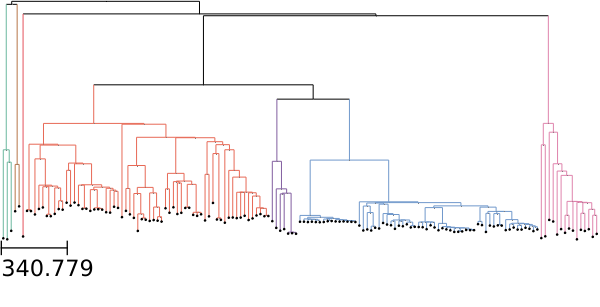

In [119]:
in_Tree = Mtb_151CI_Tree_V1.copy()
in_Tree.render("%%inline", w = 600, tree_style = ts_ColLin)

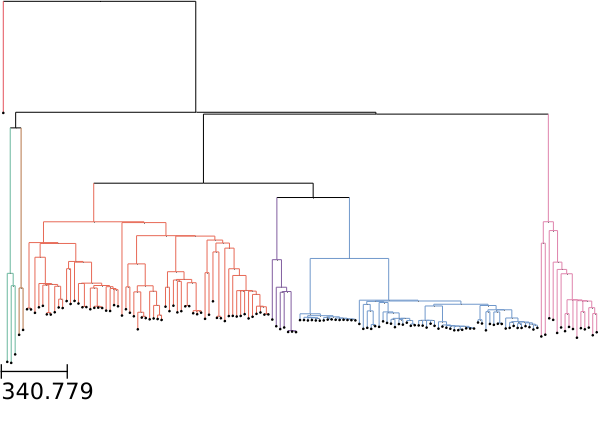

In [120]:
in_Tree = Mtb_151CI_Tree_WiL8Root_V1.copy()
in_Tree.render("%%inline", w = 600, tree_style = ts_ColLin)

In [121]:
# in_Tree = Mtb_151CI_Tree_V1.copy()
# in_Tree.render("%%inline", w = 800, tree_style = ts_ColLin_circ)

In [122]:
# in_Tree = Mtb_151CI_Tree_V1.copy()
# in_Tree.render("%%inline", w = 800, tree_style = ts_ColLin_FullCirc)

### Viz `Mtb151CI` Tree - `Custom Matplotlib tree viz Function`

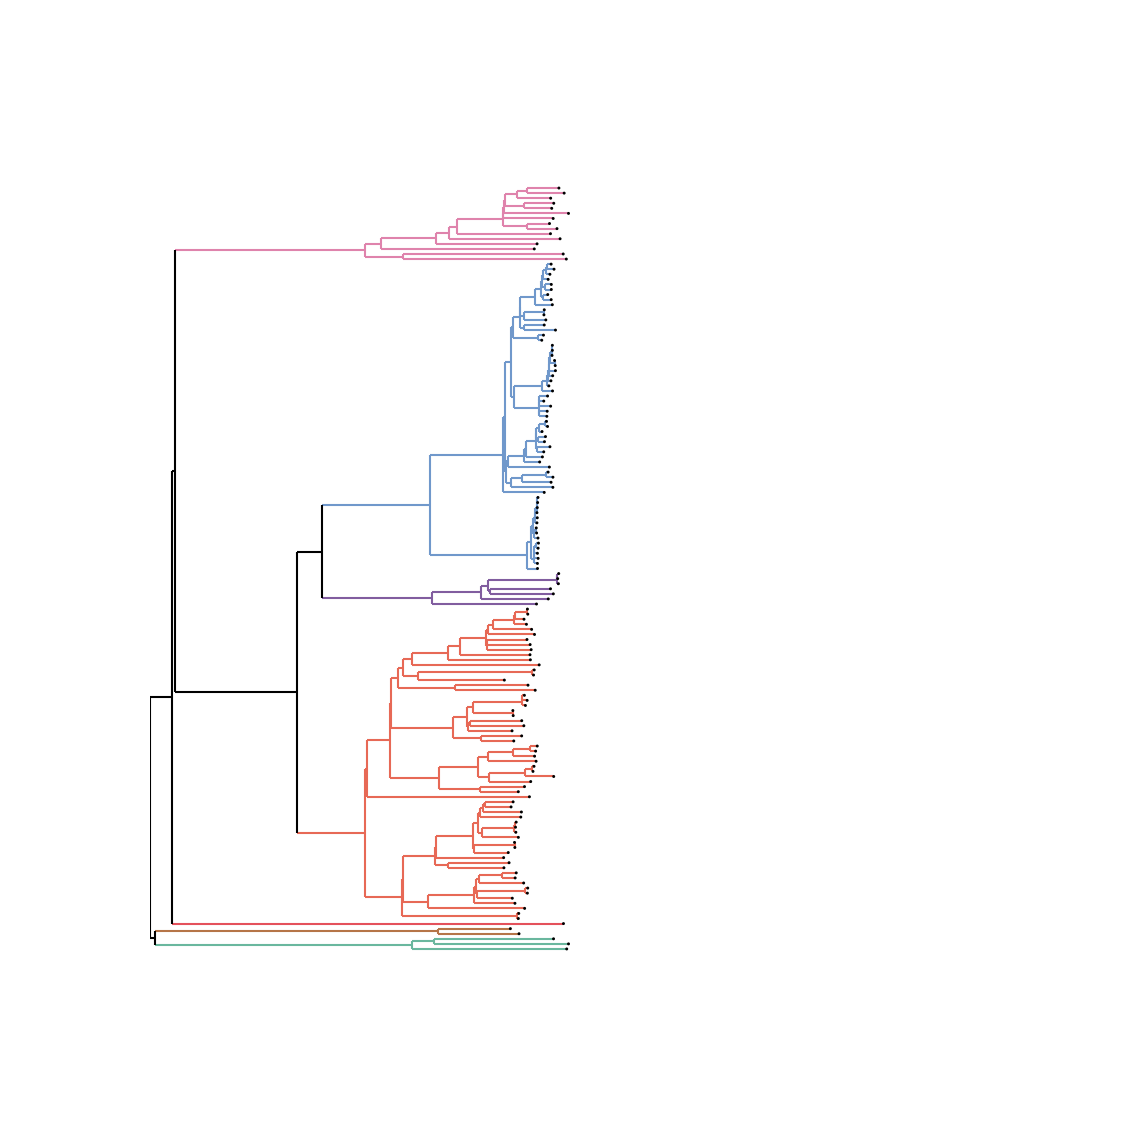

In [123]:
fig, ax_1 = plt.subplots(figsize=(3, 3))

### 1) Plot tree on ax1 axis
coords, NameToCoords = mpl_plot_tree(Mtb_151CI_Tree_V1,
                                     name_offset=0.7,
                                     axe=ax_1,
                                     show_names=False,
                                     draw_leaf_nodes=True,
                                     leaf_node_size=1.0,
                                     pad_right=1,
                                     show_scale_bar = False,
                                     )

#fig

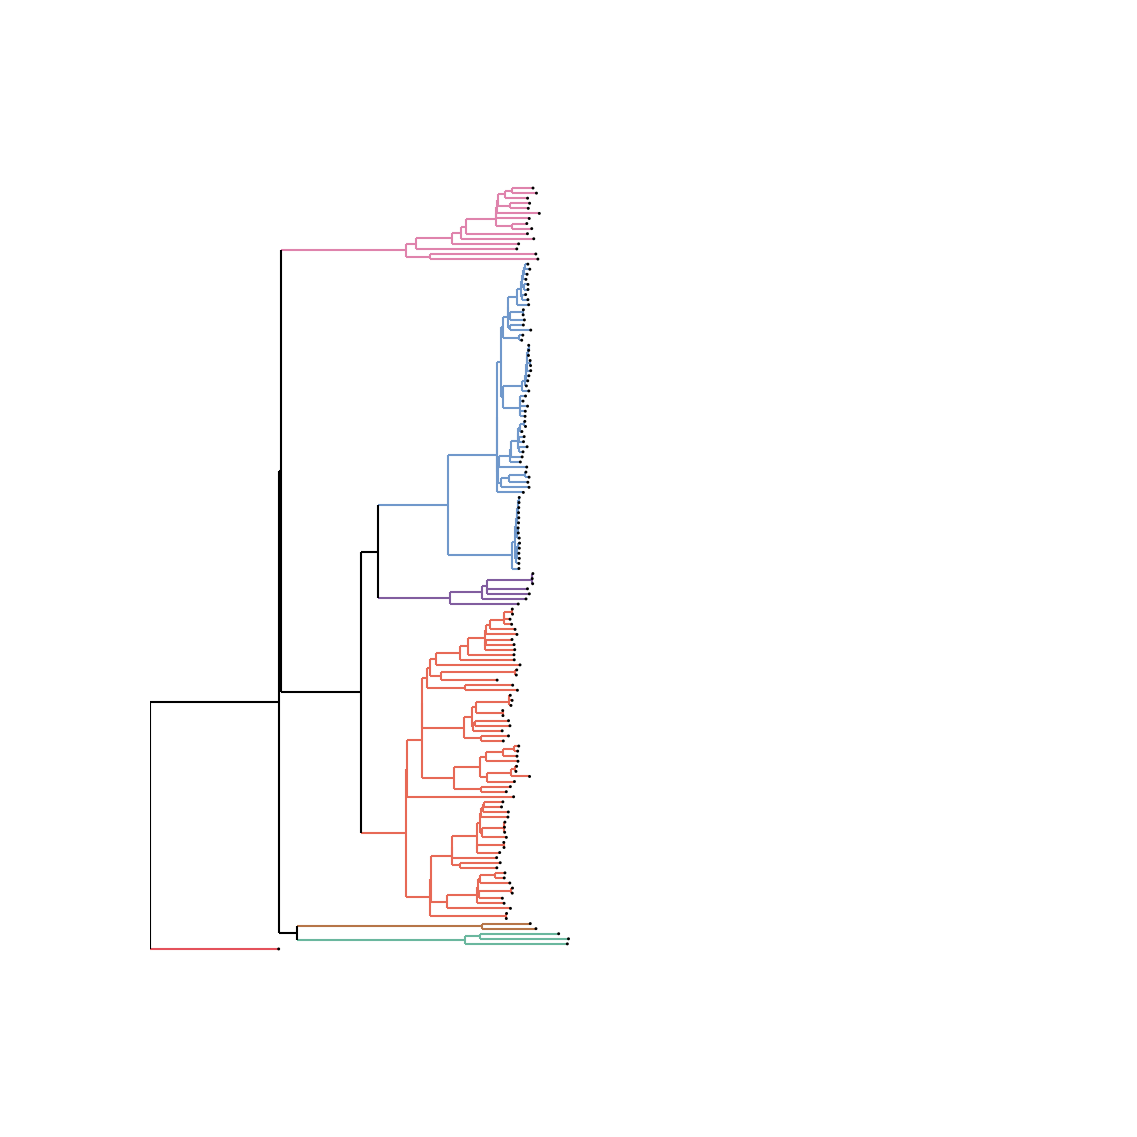

In [124]:
fig, ax_1 = plt.subplots(figsize=(3, 3))

### 1) Plot tree on ax1 axis
coords, NameToCoords = mpl_plot_tree(Mtb_151CI_Tree_WiL8Root_V1,
                                     name_offset=0.7,
                                     axe=ax_1,
                                     show_names=False,
                                     draw_leaf_nodes=True,
                                     leaf_node_size=1.0,
                                     pad_right=1,
                                     show_scale_bar = False,
                                     )

#fig

# Classify & Divide sets of GC Events based on Paralog Mapping results

In [125]:
GCE_All_DF = GRE_AnnoByMatch_DF
GCE_ABM_DF = GRE_AnnoByMatch_DF

# Seperate GC Event Info DF into GCEs WITH and WITHOUT paralogs
GCE_InPR_DF = GCE_All_DF.query("NumHmTargets > 0")
GCE_NotInPR_DF = GCE_All_DF.query("NumHmTargets == 0")

mGCE_DF = GRE_AnnoByMatch_DF.query("MappedEvent == True") #.query("Max_KmerMatch_ToHm > 0.5")
GCE_Mapped_DF = mGCE_DF

GCE_NotMapped_DF = GRE_AnnoByMatch_DF.query("MappedEvent == False") #.query("Max_KmerMatch_ToHm <= 0.5")

GCE_NotMapped_InPR_DF = GCE_NotMapped_DF.query("NumHmTargets > 0")

GCE_NotMapped_NotInPR_DF = GCE_NotMapped_DF.query("NumHmTargets == 0")


print("# of TOTAL detected events", GCE_All_DF.shape[0])

print("# of detected events IN a Paralog-Region:", GCE_InPR_DF.shape[0])
print("# of detected events NOT IN a Paralog-Region:", GCE_NotInPR_DF.shape[0])
print("")
print("# of mapped events", GCE_Mapped_DF.shape[0])
print("# of NOT MAPPED events:", GCE_NotMapped_DF.shape[0])

print("# of NOT MAPPED events IN a Paralog-Region:", GCE_NotMapped_InPR_DF.shape[0])
#print("# of NOT MAPPED events NOT IN a Paralog-Region:", GCE_NotMapped_NotInPR_DF.shape[0])


# of TOTAL detected events 324
# of detected events IN a Paralog-Region: 295
# of detected events NOT IN a Paralog-Region: 29

# of mapped events 217
# of NOT MAPPED events: 107
# of NOT MAPPED events IN a Paralog-Region: 78


### Get all TOP matches to paralogs for each GCE

In [126]:
GRE_MatchToHm_DF.shape

(590, 15)

In [127]:
GCE_Mapped_DF.shape

(217, 47)

In [128]:
mGCEToParalogs_TopKmerMatches_Info_DF = getEventKmerMatchInfo_TopParalogMatches(GCE_Mapped_DF,
                                                                                GRE_MatchToHm_DF)

mGCEToParalogs_TopKmerMatches_Info_DF.shape

(248, 14)

In [129]:
mGCEToParalogs_TopKmerMatches_Info_DF["EventID"].nunique()

217

# Part 1: Analysis of overlap between GC events & NucDiv hotspots


### Create a 1-kb window summary of NucDiv, mGC + pGC event counts, and HHR overlap

In [130]:
RE_CoordCols = ("seqname", "start_0based", "end_1based")
GenomeAnno_CoordCols = ("Chrom", "Start", "End")
Hm_Query_CoordCols = ("Query_Name", "Query_Start", "Query_End")
Hm_Target_CoordCols = ("Target_Name", "Target_Start", "Target_End")
NucDiv_CoordCols = ("Chrom", "Start", "End")

NucDiv_WiGCECt_DF = bf.count_overlaps(WGA_NucDiv_PI_1kb_DF,
                                      GCE_Mapped_DF,
                                      cols1 = ("Chrom", "Start", "End"),
                                      cols2 = RE_CoordCols).rename(columns={'count': 'N_mGCE'})

NucDiv_WiGCECt_DF = bf.count_overlaps(NucDiv_WiGCECt_DF,
                                      GRE_ABM_DF,
                                      cols1 = ("Chrom", "Start", "End"),
                                      cols2 = RE_CoordCols).rename(columns={'count': 'N_pGCE'})

NucDiv_WiGCECt_DF = bf.count_overlaps(NucDiv_WiGCECt_DF,
                                          HmMap_Aln_k19w19_NoOverlap_DF, 
                                          cols1 = NucDiv_CoordCols,
                                          cols2 = Hm_Target_CoordCols ).rename(columns={'count': 'N_Ovrlap_ParalogAlns'})

#### Add counts of (TOTAL Paralog-SNPs per HmRegion)

NucDiv_WiGCECt_DF = bf.count_overlaps(NucDiv_WiGCECt_DF,
                                              Mtb_HM_Var_PR_SNPs_DF,
                                              cols1 = ("Chrom", "Start", "End"),
                                              cols2 = Hm_Target_CoordCols).rename(columns={'count': 'Num_PR_SNPs_All'})

#### Add counts of UNIQUE PR-SNPs per HmRegion
NucDiv_WiGCECt_DF = bf.count_overlaps(NucDiv_WiGCECt_DF,
                                      Mtb_HM_Var_PR_SNPs_Trim_TrimUnq_DF,
                                      cols1 = ("Chrom", "Start", "End"),
                                      cols2 = Hm_Target_CoordCols).rename(columns={'count': 'Num_PR_SNPs_Unq'})

NucDiv_WiGCECt_DF.shape


(4421, 25)

### Get 1-kb windows w/ GCEs detected BUT W/ NO OVERLAP W/ PARALOG REGION

In [131]:
GCE_NotInPR_DF.shape

(29, 47)

In [132]:
Rv_1kb_NucDiv_GCE_DF = NucDiv_WiGCECt_DF

RvWin_CoordCols = ("Chrom", "Start", "End")

Rv_1kb_NucDiv_GCE_DF = bf.count_overlaps(Rv_1kb_NucDiv_GCE_DF,
                                         GCE_NotInPR_DF,
                                         cols1 = RvWin_CoordCols,
                                         cols2 = RE_CoordCols).rename(columns={'count': 'N_GCE_NoParalogRegionOvrlap'})

Rv_1kb_NucDiv_GCE_DF.shape

(4421, 26)

In [133]:
Rv_1kb_NucDiv_GCE_NoPR_DF = Rv_1kb_NucDiv_GCE_DF.query("N_GCE_NoParalogRegionOvrlap > 0")
Rv_1kb_NucDiv_GCE_NoPR_DF.shape

(18, 26)

#### Per LocalRepeat Region - Count # of GCEs with NO PR overlap 

In [134]:
RE_CoordCols = ("seqname", "start_0based", "end_1based")
HmRegion_CoordCols = ("Chr", "Start", "End")

GCE_PerLRStats_V2_DF = bf.count_overlaps(GCE_PerLRStats_DF,
                                         GCE_NotInPR_DF,
                                         cols1 = HmRegion_CoordCols,
                                         cols2 = RE_CoordCols).rename(columns={'count': 'N_GCE_NoParalogRegionOvrlap'})

GCE_PerLRStats_V2_DF = bf.count_overlaps(GCE_PerLRStats_V2_DF,
                                         GCE_InPR_DF,
                                         cols1 = HmRegion_CoordCols,
                                         cols2 = RE_CoordCols).rename(columns={'count': 'N_GCE_InParalogRegionOvrlap'})

GCE_PerLRStats_V2_DF.shape

(50, 18)

In [135]:
GCE_PerLRStats_V2_DF.query("pGCE_Count > 0").shape

(11, 18)

In [136]:
GCE_PerLRStats_V2_DF.query("N_GCE_NoParalogRegionOvrlap > 0 & N_GCE_InParalogRegionOvrlap == 0").shape

(5, 18)

In [137]:
GCE_PerLRStats_V2_DF.query("N_GCE_NoParalogRegionOvrlap == 0 & N_GCE_InParalogRegionOvrlap > 0").shape

(4, 18)

In [138]:
GCE_PerLRStats_V2_DF.query("N_GCE_NoParalogRegionOvrlap > 0 & N_GCE_InParalogRegionOvrlap > 0").shape

(2, 18)

In [139]:
GCE_PerLRStats_V2_DF.head(3)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,pGCE_Count,CenterOfRegion,Overlap_GC_EventIDs,N_GCE_NoParalogRegionOvrlap,N_GCE_InParalogRegionOvrlap
0,0,NC_000962.3,333811,335879,334845.0,2068,PE_PGRS3,0,1,1,1,0,LR_HmRegion_000,1,334845.0,Event_036,0,1
1,1,NC_000962.3,366430,375121,370775.5,8691,"PPE5,PPE6",0,6,6,6,1,LR_HmRegion_001,0,370775.5,_,0,0
2,2,NC_000962.3,424011,432951,428481.0,8940,"hspR,PPE7,PPE8",0,5,4,4,2,LR_HmRegion_002,0,428481.0,_,0,0


#### Look at the 5 Local Repeat Regions (LRRs) w/ GCEs detected (And no PR)

In [140]:
list(GCE_PerLRStats_V2_DF.query("N_GCE_NoParalogRegionOvrlap > 0 & N_GCE_InParalogRegionOvrlap == 0")["Overlap_Genes"].values)

['PE_PGRS22',
 'PPE16,Rv1135A,Rv1136,Rv1137c,Rv1138c,Rv1139c',
 'Rv1318c,Rv1319c,Rv1320c',
 'PPE34,PPE35',
 'Rv2980,ddlA']

In [141]:
GCE_PerLRStats_V2_DF.query("N_GCE_NoParalogRegionOvrlap > 0 & N_GCE_InParalogRegionOvrlap == 0")

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,pGCE_Count,CenterOfRegion,Overlap_GC_EventIDs,N_GCE_NoParalogRegionOvrlap,N_GCE_InParalogRegionOvrlap
9,9,NC_000962.3,1217612,1218128,1217870.0,516,PE_PGRS22,0,2,2,2,9,LR_HmRegion_009,1,1217870.0,Event_082,1,0
10,10,NC_000962.3,1263098,1267244,1265171.0,4146,"PPE16,Rv1135A,Rv1136,Rv1137c,Rv1138c,Rv1139c",0,1,1,1,10,LR_HmRegion_010,1,1265171.0,Event_083,1,0
14,14,NC_000962.3,1479277,1484143,1481710.0,4866,"Rv1318c,Rv1319c,Rv1320c",0,2,2,2,14,LR_HmRegion_014,1,1481710.0,Event_109,1,0
21,21,NC_000962.3,2163327,2169168,2166247.5,5841,"PPE34,PPE35",0,4,4,4,21,LR_HmRegion_021,8,2166247.5,"Event_175,Event_176,Event_177,Event_178,Event_...",8,0
37,37,NC_000962.3,3336503,3336802,3336652.5,299,"Rv2980,ddlA",0,3,3,2,37,LR_HmRegion_037,1,3336652.5,Event_239,1,0


# ID PRs of interest (For Downstream Viz)

In [142]:
GRE_PerPRStats_DF.shape

(200, 18)

In [143]:
GRE_PerPRStats_DF.head(3)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,pGCE_Count,CenterOfRegion,Overlap_GC_EventIDs
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000,0,PR_Set_1,0,80353.5,_
1,1,NC_000962.3,80623,82664,81643.5,2041,"Rv0072,Rv0073",0,1,1,1,1,PR_HmRegion_001,0,PR_Set_2,0,81643.5,_
2,2,NC_000962.3,103705,105130,104417.5,1425,"Rv0094c,Rv0095c",0,2,2,2,2,PR_HmRegion_002,0,PR_Set_3,31,104417.5,"Event_001,Event_002,Event_003,Event_004,Event_..."


In [144]:
GRE_PerPRStats_DF.query("pGCE_Count > 0").shape

(54, 18)

In [145]:
HmRegions_DonorAndEventCt_DF.sort_values("N_Events_Putative", ascending = False).head(20)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,Norm_Donor_Count,N_Events_Mapped,N_Events_Putative,EventSkew,DonAccCt,EventSkew_Norm,GCE_FractionMapped,Num_PR_SNPs_All,Num_PR_SNPs_Unq
2,2,NC_000962.3,103705,105130,104417.5,1425,"Rv0094c,Rv0095c",0,2,2,2,2,PR_HmRegion_002,0,PR_Set_3,10.50,19,31,8.50,29.50,0.288136,0.612903,68,35
65,65,NC_000962.3,1636705,1639561,1638133.0,2856,"PE_PGRS28,Rv1453",0,3,3,3,65,PR_HmRegion_065,0,PR_Set_23,14.00,19,21,5.00,33.00,0.151515,0.904762,429,424
64,64,NC_000962.3,1633310,1634790,1634050.0,1480,PE_PGRS27,0,2,2,2,64,PR_HmRegion_064,0,PR_Set_23,19.00,14,19,-5.00,33.00,-0.151515,0.736842,184,184
180,180,NC_000962.3,3883535,3884921,3884228.0,1386,"Rv3466,Rv3467",0,2,2,1,180,PR_HmRegion_180,0,PR_Set_3,13.00,8,17,-5.00,21.00,-0.238095,0.470588,37,35
183,183,NC_000962.3,3930988,3936438,3933713.0,5450,PE_PGRS54,0,6,6,6,183,PR_HmRegion_183,0,PR_Set_10,3.00,4,16,1.00,7.00,0.142857,0.250000,1705,1336
94,94,NC_000962.3,2195856,2197360,2196608.0,1504,"Rv1944c,Rv1945",0,1,1,1,94,PR_HmRegion_094,0,PR_Set_34,6.00,11,11,5.00,17.00,0.294118,1.000000,62,62
54,54,NC_000962.3,1340494,1341292,1340893.0,798,"PPE18,esxK,esxL",0,4,4,4,54,PR_HmRegion_054,0,PR_Set_28,9.25,9,11,-0.25,18.25,-0.013699,0.818182,87,53
74,74,NC_000962.3,1788513,1789865,1789189.0,1352,"Rv1587c,Rv1588c",0,2,2,1,74,PR_HmRegion_074,0,PR_Set_3,11.50,8,10,-3.50,19.50,-0.179487,0.800000,35,35
10,10,NC_000962.3,336565,339142,337853.5,2577,PE_PGRS4,0,2,2,2,10,PR_HmRegion_010,0,PR_Set_10,2.00,6,10,4.00,8.00,0.500000,0.600000,732,629
113,113,NC_000962.3,2625885,2626683,2626284.0,798,"esxO,esxP,Rv2348c",0,4,4,4,113,PR_HmRegion_113,0,PR_Set_28,4.75,10,10,5.25,14.75,0.355932,1.000000,104,52


In [146]:
HmRegions_DonorAndEventCt_DF.head(4)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,Norm_Donor_Count,N_Events_Mapped,N_Events_Putative,EventSkew,DonAccCt,EventSkew_Norm,GCE_FractionMapped,Num_PR_SNPs_All,Num_PR_SNPs_Unq
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000,0,PR_Set_1,0.0,0,0,0.0,0.0,0.000000,0.000000,20,20
1,1,NC_000962.3,80623,82664,81643.5,2041,"Rv0072,Rv0073",0,1,1,1,1,PR_HmRegion_001,0,PR_Set_2,0.0,0,0,0.0,0.0,0.000000,0.000000,374,374
2,2,NC_000962.3,103705,105130,104417.5,1425,"Rv0094c,Rv0095c",0,2,2,2,2,PR_HmRegion_002,0,PR_Set_3,10.5,19,31,8.5,29.5,0.288136,0.612903,68,35
3,3,NC_000962.3,149571,149808,149689.5,237,PE_PGRS2,0,1,1,1,3,PR_HmRegion_003,0,PR_Set_4,0.0,0,0,0.0,0.0,0.000000,0.000000,38,38


In [147]:
HmRegions_DonorAndEventCt_DF.query("N_Events_Putative >= 1").shape

(54, 24)

In [148]:
HmRegions_DonorAndEventCt_ModPN10_DF.query("N_Events_Putative >= 2").shape

(45, 24)

In [149]:
HmRegions_DonorAndEventCt_ModPN10_DF.query("N_Events_Putative >= 1").shape

(56, 24)

/tmp/ipykernel_3868776/2113206519.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pr_df["RegionLabel"] = pr_df["HmRegion_Num"].astype(str) + " - " + pr_df["Overlap_Genes"].fillna("NA")


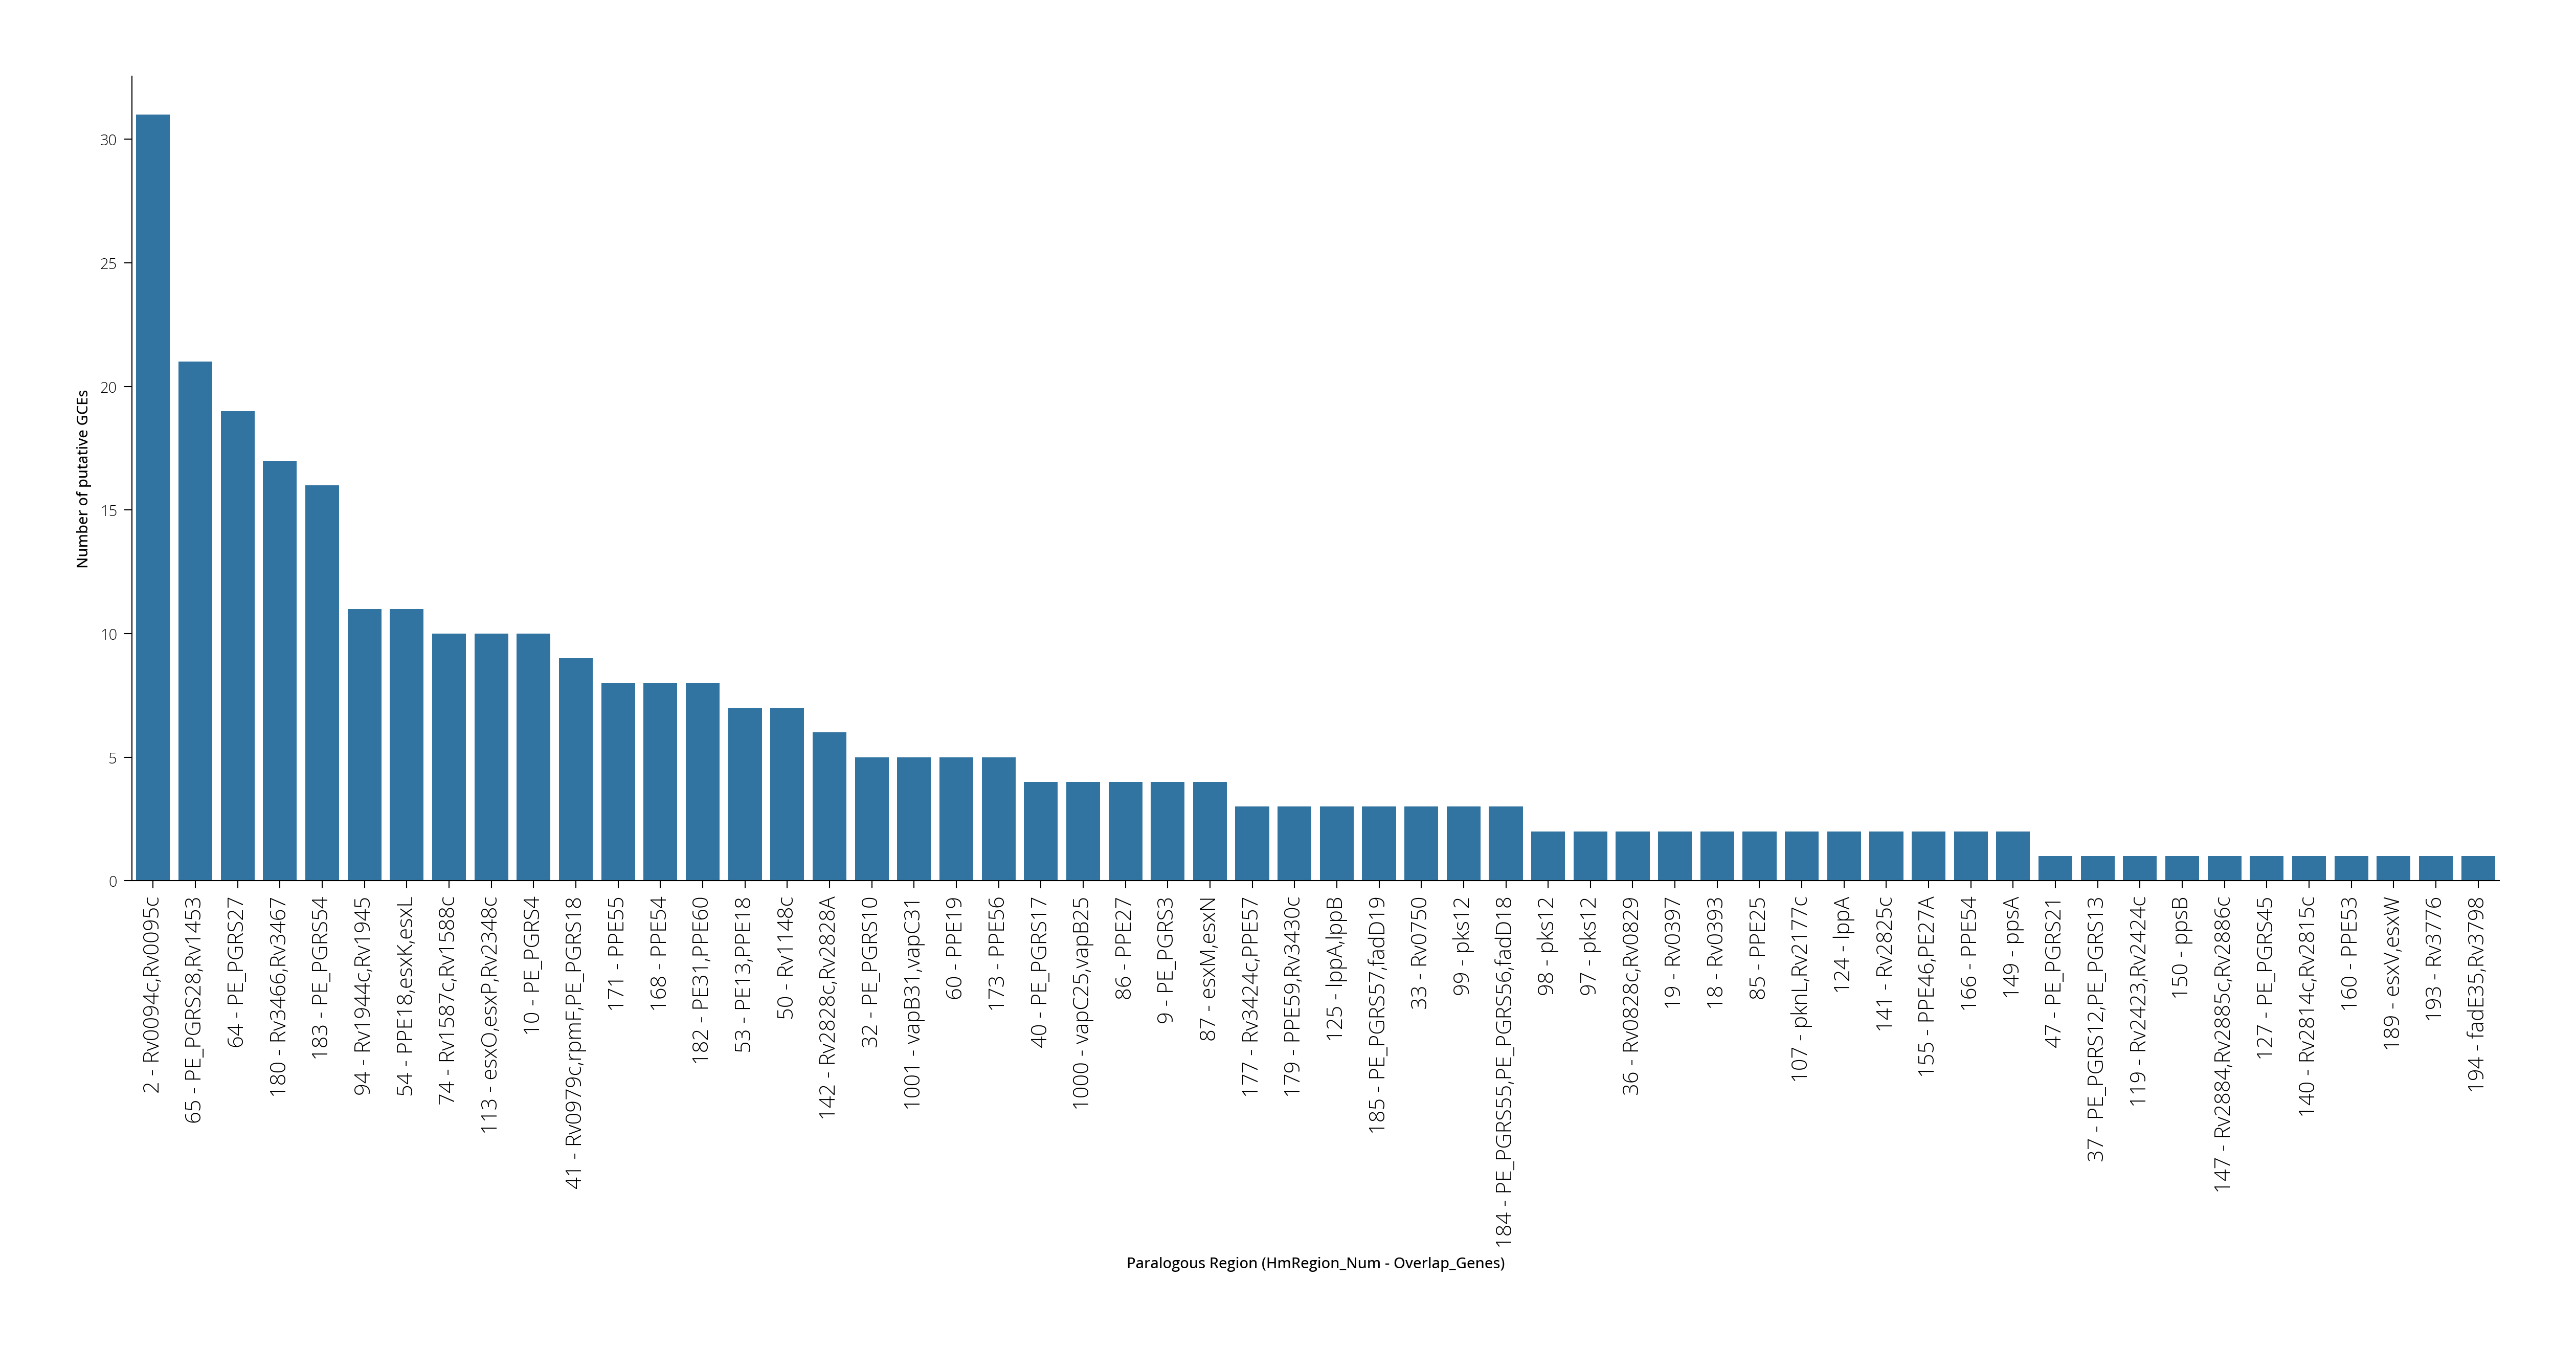

In [150]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataframe
pr_df = HmRegions_DonorAndEventCt_ModPN10_DF.query("N_Events_Putative >= 1")

# Construct the combined region label
pr_df["RegionLabel"] = pr_df["HmRegion_Num"].astype(str) + " - " + pr_df["Overlap_Genes"].fillna("NA")

# Sort by putative event count (descending)
plot_df = (
    pr_df.sort_values("N_Events_Putative", ascending=False)
         .reset_index(drop=True)
)

plt.figure(figsize=(16, 8))

sns.barplot(
    data=plot_df,
    x="RegionLabel",
    y="N_Events_Putative",
    color="tab:blue"
)

plt.ylabel("Number of putative GCEs")
plt.xlabel("Paralogous Region (HmRegion_Num - Overlap_Genes)")

# Rotate labels so they fit
plt.xticks(rotation=90, fontsize=10)
#plt.xticks([])

sns.despine()
plt.tight_layout()
plt.show()


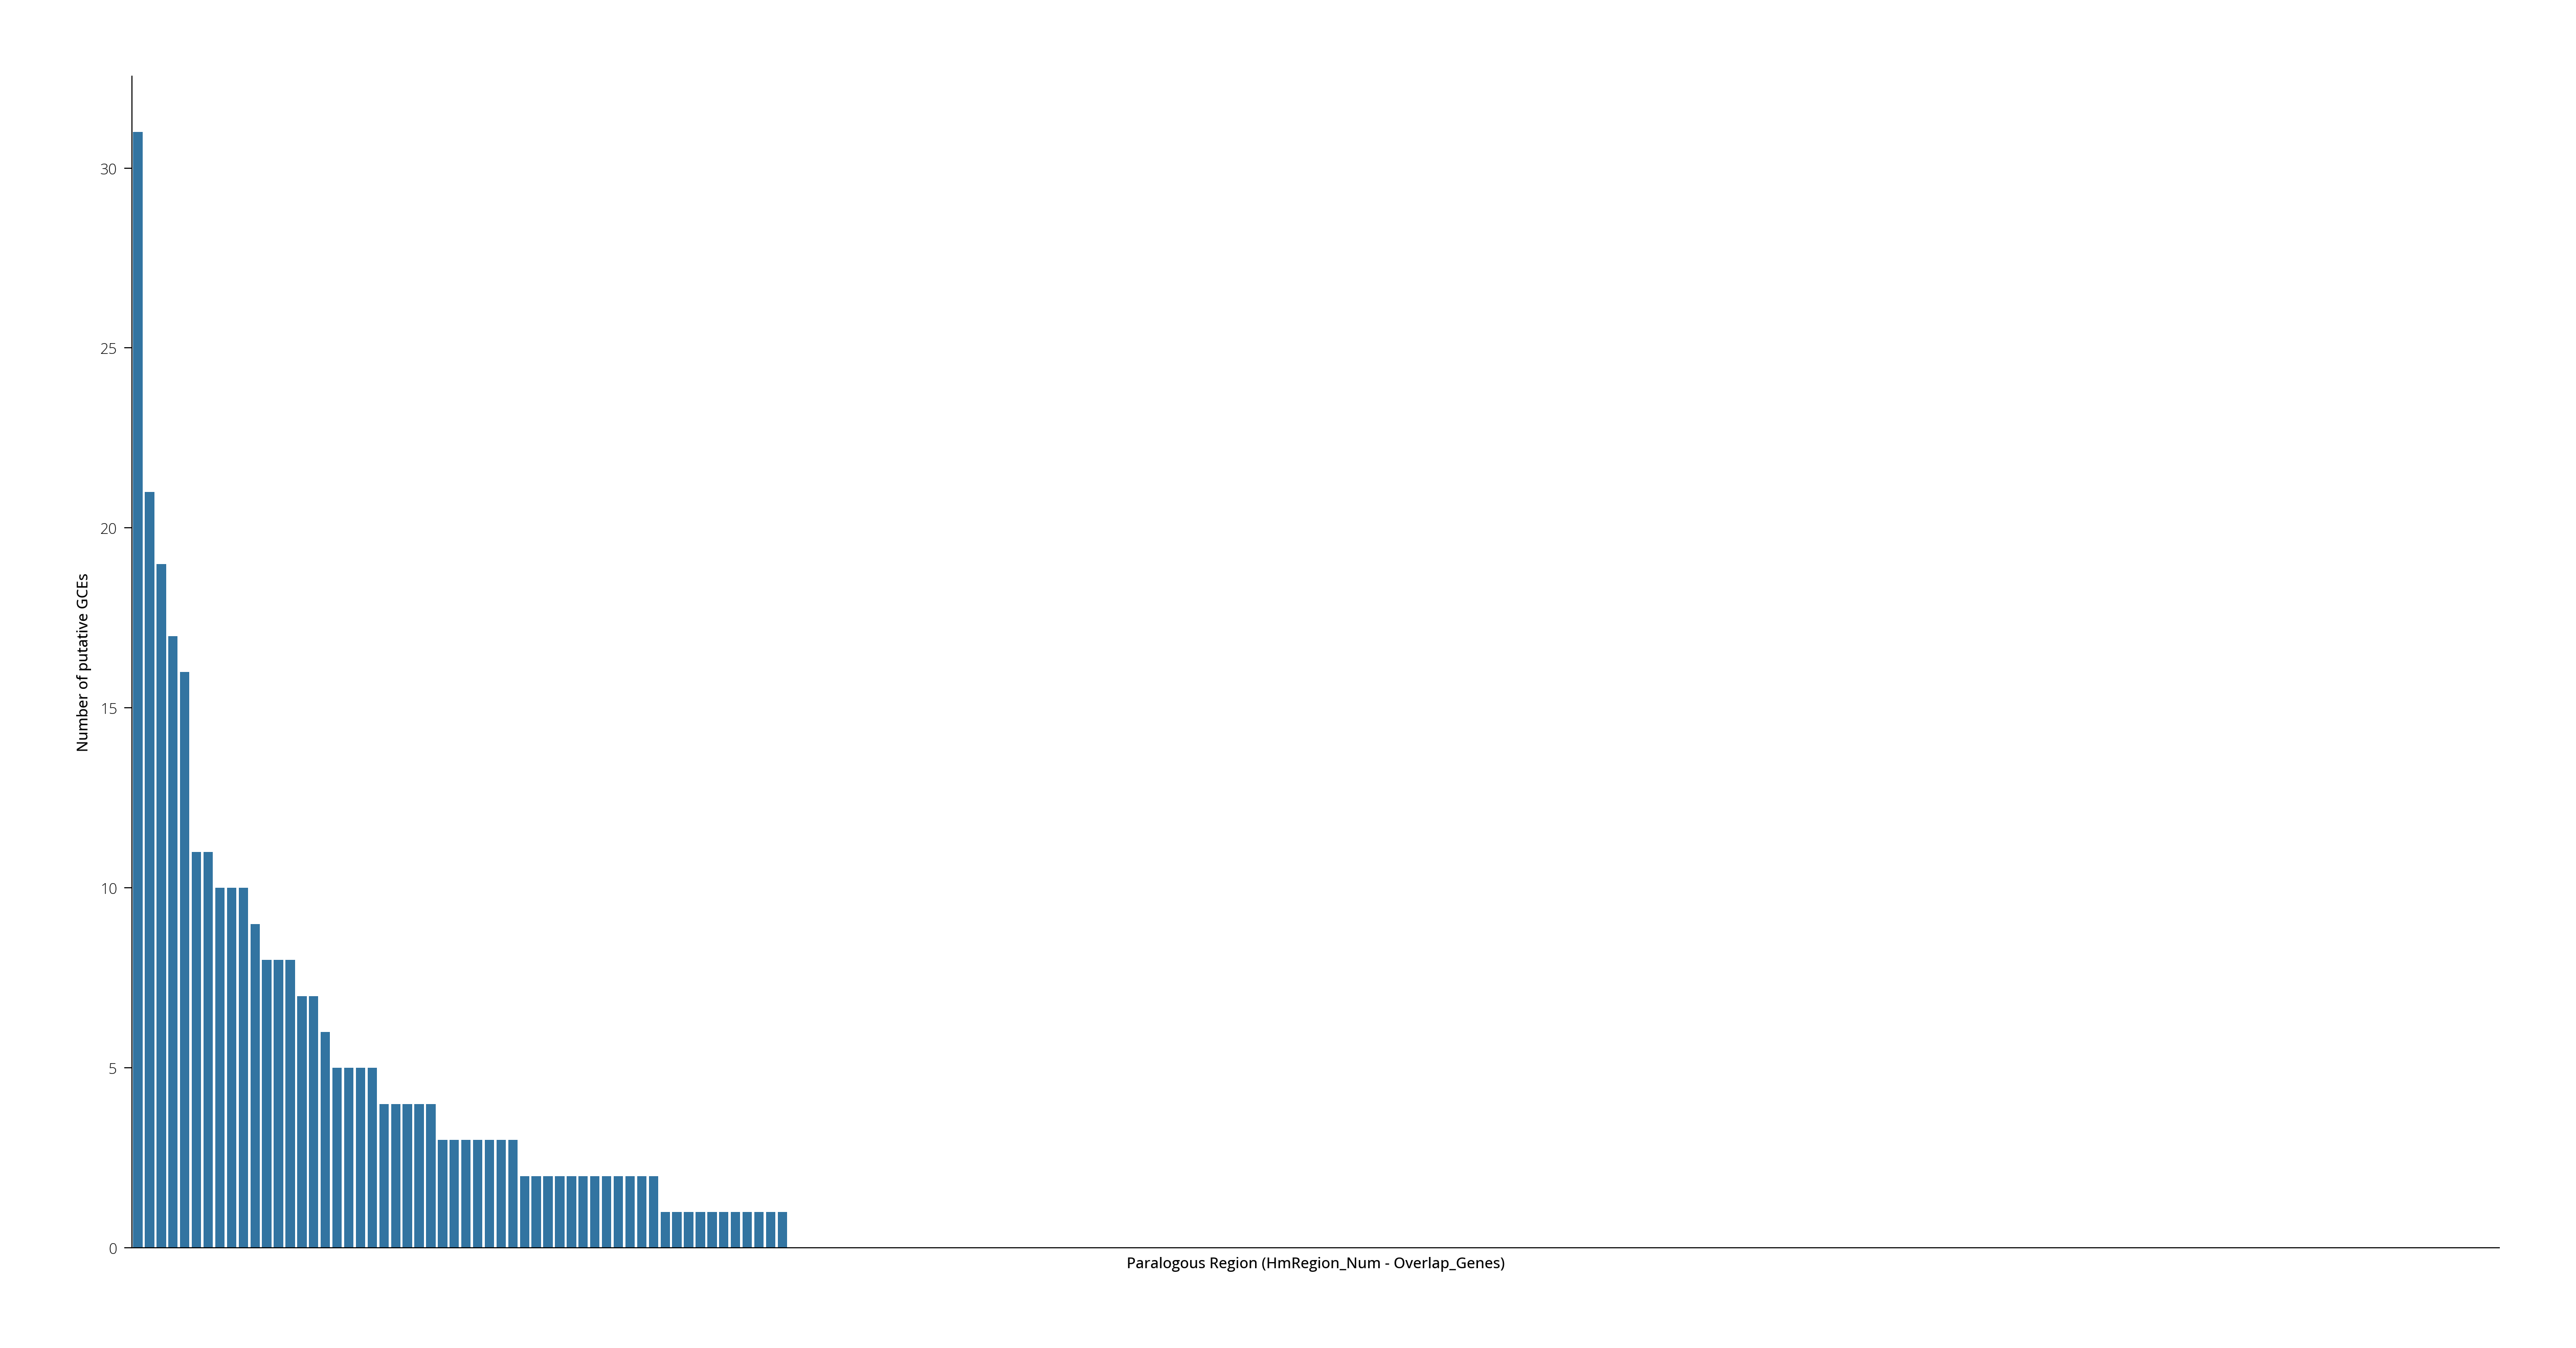

In [151]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataframe
pr_df = HmRegions_DonorAndEventCt_ModPN10_DF

# Construct the combined region label
pr_df["RegionLabel"] = pr_df["HmRegion_Num"].astype(str) + " - " + pr_df["Overlap_Genes"].fillna("NA")

# Sort by putative event count (descending)
plot_df = (
    pr_df.sort_values("N_Events_Putative", ascending=False)
         .reset_index(drop=True)
)

plt.figure(figsize=(16, 8))

sns.barplot(
    data=plot_df,
    x="RegionLabel",
    y="N_Events_Putative",
    color="tab:blue"
)

plt.ylabel("Number of putative GCEs")
plt.xlabel("Paralogous Region (HmRegion_Num - Overlap_Genes)")

# Rotate labels so they fit
#plt.xticks(rotation=90, fontsize=10)
plt.xticks([])

sns.despine()
plt.tight_layout()
plt.show()


# Begin Analysis

In [152]:
PRs_WiAnyGCE_DF = HmRegions_DonorAndEventCt_ModPN10_DF.query("N_Events_Putative >= 1"
                                                            ).sort_values("N_Events_Putative", ascending=False
                                                            ).reset_index(drop=True)



LRRs_WiAnyGCE_DF = GCE_PerLRStats_V2_DF.query("N_GCE_NoParalogRegionOvrlap > 0 & N_GCE_InParalogRegionOvrlap == 0")



In [153]:
PRs_WiAnyGCE_DF.shape

(56, 25)

In [154]:
LRRs_WiAnyGCE_DF.shape

(5, 18)

In [155]:
PRs_WiAnyGCE_DF.head(4)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,Norm_Donor_Count,N_Events_Mapped,N_Events_Putative,EventSkew,DonAccCt,EventSkew_Norm,GCE_FractionMapped,Num_PR_SNPs_All,Num_PR_SNPs_Unq,RegionLabel
0,2,NC_000962.3,103705,105130,104417.5,1425,"Rv0094c,Rv0095c",0,2,2,2,2,PR_HmRegion_002,0,PR_Set_3,10.5,19,31,8.5,29.5,0.288136,0.612903,68,35,"2 - Rv0094c,Rv0095c"
1,65,NC_000962.3,1636705,1639561,1638133.0,2856,"PE_PGRS28,Rv1453",0,3,3,3,65,PR_HmRegion_065,0,PR_Set_23,14.0,19,21,5.0,33.0,0.151515,0.904762,429,424,"65 - PE_PGRS28,Rv1453"
2,64,NC_000962.3,1633310,1634790,1634050.0,1480,PE_PGRS27,0,2,2,2,64,PR_HmRegion_064,0,PR_Set_23,19.0,14,19,-5.0,33.0,-0.151515,0.736842,184,184,64 - PE_PGRS27
3,180,NC_000962.3,3883535,3884921,3884228.0,1386,"Rv3466,Rv3467",0,2,2,1,180,PR_HmRegion_180,0,PR_Set_3,13.0,8,17,-5.0,21.0,-0.238095,0.470588,37,35,"180 - Rv3466,Rv3467"


In [156]:
#Rv_1kb_NucDiv_GCE_NoPR_DF

In [157]:
PRs_WiAnyGCE_DF.head()  

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,Norm_Donor_Count,N_Events_Mapped,N_Events_Putative,EventSkew,DonAccCt,EventSkew_Norm,GCE_FractionMapped,Num_PR_SNPs_All,Num_PR_SNPs_Unq,RegionLabel
0,2,NC_000962.3,103705,105130,104417.5,1425,"Rv0094c,Rv0095c",0,2,2,2,2,PR_HmRegion_002,0,PR_Set_3,10.5,19,31,8.5,29.5,0.288136,0.612903,68,35,"2 - Rv0094c,Rv0095c"
1,65,NC_000962.3,1636705,1639561,1638133.0,2856,"PE_PGRS28,Rv1453",0,3,3,3,65,PR_HmRegion_065,0,PR_Set_23,14.0,19,21,5.0,33.0,0.151515,0.904762,429,424,"65 - PE_PGRS28,Rv1453"
2,64,NC_000962.3,1633310,1634790,1634050.0,1480,PE_PGRS27,0,2,2,2,64,PR_HmRegion_064,0,PR_Set_23,19.0,14,19,-5.0,33.0,-0.151515,0.736842,184,184,64 - PE_PGRS27
3,180,NC_000962.3,3883535,3884921,3884228.0,1386,"Rv3466,Rv3467",0,2,2,1,180,PR_HmRegion_180,0,PR_Set_3,13.0,8,17,-5.0,21.0,-0.238095,0.470588,37,35,"180 - Rv3466,Rv3467"
4,183,NC_000962.3,3930988,3936438,3933713.0,5450,PE_PGRS54,0,6,6,6,183,PR_HmRegion_183,0,PR_Set_10,3.0,4,16,1.0,7.0,0.142857,0.250000,1705,1336,183 - PE_PGRS54


In [158]:
PRs_WiAnyGCE_DF.sort_values("N_Events_Putative", ascending=False).head(10)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,Norm_Donor_Count,N_Events_Mapped,N_Events_Putative,EventSkew,DonAccCt,EventSkew_Norm,GCE_FractionMapped,Num_PR_SNPs_All,Num_PR_SNPs_Unq,RegionLabel
0,2,NC_000962.3,103705,105130,104417.5,1425,"Rv0094c,Rv0095c",0,2,2,2,2,PR_HmRegion_002,0,PR_Set_3,10.50,19,31,8.50,29.50,0.288136,0.612903,68,35,"2 - Rv0094c,Rv0095c"
1,65,NC_000962.3,1636705,1639561,1638133.0,2856,"PE_PGRS28,Rv1453",0,3,3,3,65,PR_HmRegion_065,0,PR_Set_23,14.00,19,21,5.00,33.00,0.151515,0.904762,429,424,"65 - PE_PGRS28,Rv1453"
2,64,NC_000962.3,1633310,1634790,1634050.0,1480,PE_PGRS27,0,2,2,2,64,PR_HmRegion_064,0,PR_Set_23,19.00,14,19,-5.00,33.00,-0.151515,0.736842,184,184,64 - PE_PGRS27
3,180,NC_000962.3,3883535,3884921,3884228.0,1386,"Rv3466,Rv3467",0,2,2,1,180,PR_HmRegion_180,0,PR_Set_3,13.00,8,17,-5.00,21.00,-0.238095,0.470588,37,35,"180 - Rv3466,Rv3467"
4,183,NC_000962.3,3930988,3936438,3933713.0,5450,PE_PGRS54,0,6,6,6,183,PR_HmRegion_183,0,PR_Set_10,3.00,4,16,1.00,7.00,0.142857,0.250000,1705,1336,183 - PE_PGRS54
5,94,NC_000962.3,2195856,2197360,2196608.0,1504,"Rv1944c,Rv1945",0,1,1,1,94,PR_HmRegion_094,0,PR_Set_34,6.00,11,11,5.00,17.00,0.294118,1.000000,62,62,"94 - Rv1944c,Rv1945"
6,54,NC_000962.3,1340494,1341292,1340893.0,798,"PPE18,esxK,esxL",0,4,4,4,54,PR_HmRegion_054,0,PR_Set_28,9.25,9,11,-0.25,18.25,-0.013699,0.818182,87,53,"54 - PPE18,esxK,esxL"
7,74,NC_000962.3,1788513,1789865,1789189.0,1352,"Rv1587c,Rv1588c",0,2,2,1,74,PR_HmRegion_074,0,PR_Set_3,11.50,8,10,-3.50,19.50,-0.179487,0.800000,35,35,"74 - Rv1587c,Rv1588c"
8,113,NC_000962.3,2625885,2626683,2626284.0,798,"esxO,esxP,Rv2348c",0,4,4,4,113,PR_HmRegion_113,0,PR_Set_28,4.75,10,10,5.25,14.75,0.355932,1.000000,104,52,"113 - esxO,esxP,Rv2348c"
9,10,NC_000962.3,336565,339142,337853.5,2577,PE_PGRS4,0,2,2,2,10,PR_HmRegion_010,0,PR_Set_10,2.00,6,10,4.00,8.00,0.500000,0.600000,732,629,10 - PE_PGRS4


In [159]:
PRs_WiAnyGCE_DF.shape

(56, 25)

# Part Y: Per Paralog Region - Generate Visualizations of GCEs + Phylo Context + Paralog Variants

In [160]:
PR_GCE_Figures_Dict = {}
summaries_all = []

for idx, row in PRs_WiAnyGCE_DF.iterrows():
    
    idx_String = f"{idx:02d}"
    # --- 1) Extract region coordinates

    pad = 800
    Viz_Start = max(1, int(row["Start"]) - pad)
    Viz_End   = int(row["End"]) + pad
    
    Viz_Coords = f"NC_000962.3:{Viz_Start}-{Viz_End}"

    # --- 2) Extract metadata you care about
    overlap_genes = row["Overlap_Genes"]
    n_events_mapped = row["N_Events_Mapped"]
    n_events_putative = row["N_Events_Putative"]
    pr_id = row["HmRegionID"]
    ParalogNetwork_ID = row["PR_SetID"]

    # Define per-PR title for plots
    i_PR_title_text = (
        f"RegionID: {pr_id} | Paralog Network ID: {ParalogNetwork_ID}\n"
        f"Genes: {overlap_genes} | {Viz_Coords}\n"
        f"Mapped GCEs: {n_events_mapped} | "
        f"Putative GCEs: {n_events_putative}"
    )
    
    # --- 3) Generate figure
    PPGV_fig, PPGV_axes, PPGV_summaries = viz_region_Tree_Variants_Anno_ParalogVariants(
        Viz_Start,
        Viz_End,
        in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record,
        inputTree = Mtb_151CI_Tree_WiL8Root_V1,
        i_AllVar_DF = AllAsm_AllVar_DF,
        i_GCE_DF = GCE_All_DF,
        i_ParalogVar_DF = Mtb_HM_Var_PR_DF,
        figsize = (15, 14),
        tree_rect = (0.2, 0.1, 0.3, 0.8),
        paralogvariants_rect = (0.45, 0.95, 0.7, 0.12),
    )


    PGV_fig, PGV_axes, PGV_summaries = viz_region_Tree_Variants_Anno(
        Viz_Start,
        Viz_End,
        in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record,
        inputTree = Mtb_151CI_Tree_WiL8Root_V1,
        i_AllVar_DF = AllAsm_AllVar_DF,
        i_GCE_DF = GCE_All_DF,
        figsize = (15, 14),
        tree_rect = (0.2, 0.1, 0.3, 0.8),
    )


    GV_fig, GV_axes = plot_ParalogVars_Anno_with_GCE(Viz_Start, Viz_End, 
                                               in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record,
                                               pGCE_df = GCE_All_DF,
                                               snps_df = Gub_SNPs_V2_DF,
                                               ParalogVar_df = Mtb_HM_Var_PR_DF,
                                               GCE_color_by_CDSeffect = False,
                                               ShowVariant_Legend = False,
                                               )

    # --- 5) Apply title to ALL figures
    for fig in (PPGV_fig, PGV_fig, GV_fig):
        fig.suptitle(i_PR_title_text, fontsize=12, y=1.1)

    # --- 5) Store outputs
    PR_GCE_Figures_Dict[pr_id] = {
        "PR_ID": pr_id,
        "Viz_Start": Viz_Start,
        "Viz_End": Viz_End,
        "Overlap_Genes": overlap_genes,
        "N_Events_Mapped": n_events_mapped,
        "N_Events_Putative": n_events_putative,
        "ParalogVar_Phylo_GCE_Viz_Fig": PPGV_fig,
        "Phylo_GCE_Viz_Fig": PGV_fig,
        "ParalogVar_GCE_Viz_Fig": GV_fig,
        "ParalogVar_Phylo_GCE_Viz_Fig": PPGV_axes,
        "Phylo_GCE_Viz_Fig": PGV_axes,
        "ParalogVar_GCE_Viz_Fig": GV_axes,
    }

    outdir = Path("./PerPRViz_GCE_WiPhylo_WiParalogVar")
    outdir.mkdir(exist_ok=True)
    
    # PPGV_fig.savefig(f"{outdir}/{idx_String}.{pr_id}.{overlap_genes}.Phylo_ParalogVar_GCEs_Viz.V1.{Viz_Start}_{Viz_End}.pdf",
    #             bbox_inches="tight")


    PGV_fig.savefig(f"{outdir}/{idx_String}.{pr_id}.{overlap_genes}.Phylo_GCEs_Viz.V1.{Viz_Start}_{Viz_End}.pdf",
                bbox_inches="tight")

    GV_fig.savefig(f"{outdir}/{idx_String}.{pr_id}.{overlap_genes}.ParalogVar_GCEs_Viz.V1.{Viz_Start}_{Viz_End}.pdf",
                bbox_inches="tight")

    plt.close(PPGV_fig)
    plt.close(PGV_fig)
    plt.close(GV_fig)


(60402, 20) 370
(76, 20) 2
Rv1587c,Rv1588c-NC_000962.3:1788513-1789865 --- 103779 105130 1351
Rv3466,Rv3467-NC_000962.3:3883535-3884921 --- 103705 105090 1385
(60402, 20) 370
(76, 20) 2
Rv1587c,Rv1588c-NC_000962.3:1788513-1789865 --- 103779 105130 1351
Rv3466,Rv3467-NC_000962.3:3883535-3884921 --- 103705 105090 1385


/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:1433: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events.loc[:, "__start1__"]     = events["start"].astype(float) + 1.0
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:1434: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events.loc[:, "__end1__"]       = events["end"].astype(float)
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomev

(60402, 20) 370
(500, 20) 3
PE_PGRS9-NC_000962.3:836147-836519 --- 1637440 1637794 354
PE_PGRS27-NC_000962.3:1633310-1634790 --- 1636705 1638392 1687
Rv2370c,PE_PGRS40-NC_000962.3:2650377-2651923 --- 1638061 1639561 1500
(60402, 20) 370
(500, 20) 3
PE_PGRS9-NC_000962.3:836147-836519 --- 1637440 1637794 354
PE_PGRS27-NC_000962.3:1633310-1634790 --- 1636705 1638392 1687
Rv2370c,PE_PGRS40-NC_000962.3:2650377-2651923 --- 1638061 1639561 1500


/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:1433: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events.loc[:, "__start1__"]     = events["start"].astype(float) + 1.0
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:1434: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events.loc[:, "__end1__"]       = events["end"].astype(float)
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomev

(60402, 20) 370
(232, 20) 2
PE_PGRS9-NC_000962.3:835775-836519 --- 1633838 1634552 714
PE_PGRS28,Rv1453-NC_000962.3:1636705-1638392 --- 1633310 1634790 1480
(60402, 20) 370
(232, 20) 2
PE_PGRS9-NC_000962.3:835775-836519 --- 1633838 1634552 714
PE_PGRS28,Rv1453-NC_000962.3:1636705-1638392 --- 1633310 1634790 1480


...

/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:1433: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events.loc[:, "__start1__"]     = events["start"].astype(float) + 1.0
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:1434: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events.loc[:, "__end1__"]       = events["end"].astype(float)
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomev

(60402, 20) 370
(250, 20) 1
Rv2100-NC_000962.3:2358502-2360031 --- 4221088 4222560 1472
(60402, 20) 370
(250, 20) 1
Rv2100-NC_000962.3:2358502-2360031 --- 4221088 4222560 1472


/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:1433: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events.loc[:, "__start1__"]     = events["start"].astype(float) + 1.0
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:1434: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events.loc[:, "__end1__"]       = events["end"].astype(float)
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomev

(60402, 20) 370
(9, 20) 1
Rv1313c-NC_000962.3:1468141-1469654 --- 4252853 4254367 1514
(60402, 20) 370
(9, 20) 1
Rv1313c-NC_000962.3:1468141-1469654 --- 4252853 4254367 1514


/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:1433: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events.loc[:, "__start1__"]     = events["start"].astype(float) + 1.0
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:1434: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events.loc[:, "__end1__"]       = events["end"].astype(float)
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomev

In [161]:
PR_GCE_Figures_Dict["PR_HmRegion_002"]["ParalogVar_GCE_Viz_Fig"]

{'ParalogVar_ax': <Axes: title={'center': 'Paralogous Region Alignments'}>,
 'Genome_Anno_ax': <Axes: >,
 'GCE_ax': <Axes: xlabel='Genomic position (1-based)'>}

In [162]:
PR_GCE_Figures_Dict["PR_HmRegion_002"]["Phylo_GCE_Viz_Fig"]

{'ax1_L_Phylo': <Axes: >,
 'ax2_BR_Variants': <Axes: xlabel='Genomic position (1-based)'>,
 'ax3_UR_Anno': <Axes: >}

In [163]:
PR_GCE_Figures_Dict["PR_HmRegion_002"]["ParalogVar_Phylo_GCE_Viz_Fig"]

{'ax1_L_Phylo': <Axes: >,
 'ax2_BR_Variants': <Axes: xlabel='Genomic position (1-based)'>,
 'ax3_UR_Anno': <Axes: >,
 'ax4_UUR_ParalogVariants': <Axes: >}

In [164]:
GV_axes.keys()

dict_keys(['ParalogVar_ax', 'Genome_Anno_ax', 'GCE_ax'])

In [165]:
PPGV_axes.keys()

dict_keys(['ax1_L_Phylo', 'ax2_BR_Variants', 'ax3_UR_Anno', 'ax4_UUR_ParalogVariants'])

In [166]:
PGV_axes.keys()

dict_keys(['ax1_L_Phylo', 'ax2_BR_Variants', 'ax3_UR_Anno'])

# Merge all PDFS - GCE Viz for each region

In [167]:
from pypdf import PdfWriter
import os

pdf_dir = "./PerPRViz_GCE_WiPhylo_WiParalogVar"
out_merged_pdf = os.path.join(pdf_dir, "0.ParalogRegion.GCE_Visualizations.Merged.All.V1.pdf")

writer = PdfWriter()

for fname in sorted(os.listdir(pdf_dir)):
    if fname.endswith(".pdf") and "GCEs_Viz.V1" in fname:
        writer.append(os.path.join(pdf_dir, fname))

with open(out_merged_pdf, "wb") as f:
    writer.write(f)


In [168]:
!du -sh $out_pdf

120M	.


In [301]:
#PR_GCE_Figures_Dict["PR_HmRegion_010"]["fig"]

# Part X: Test of all Viz Types for PPE18 region

### i) Show phylogeny + variants + events + gene anno + paralog alignments

(60402, 20) 370
(177, 20) 3
PPE19-NC_000962.3:1532539-1533632 --- 1339349 1340433 1084
esxO,esxP,Rv2348c-NC_000962.3:2625885-2626683 --- 1340494 1341292 798
PE31,PPE60-NC_000962.3:3894016-3895519 --- 1338923 1340433 1510


/home/mm774/miniforge/envs/bfds_v1/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/home/mm774/miniforge/envs/bfds_v1/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


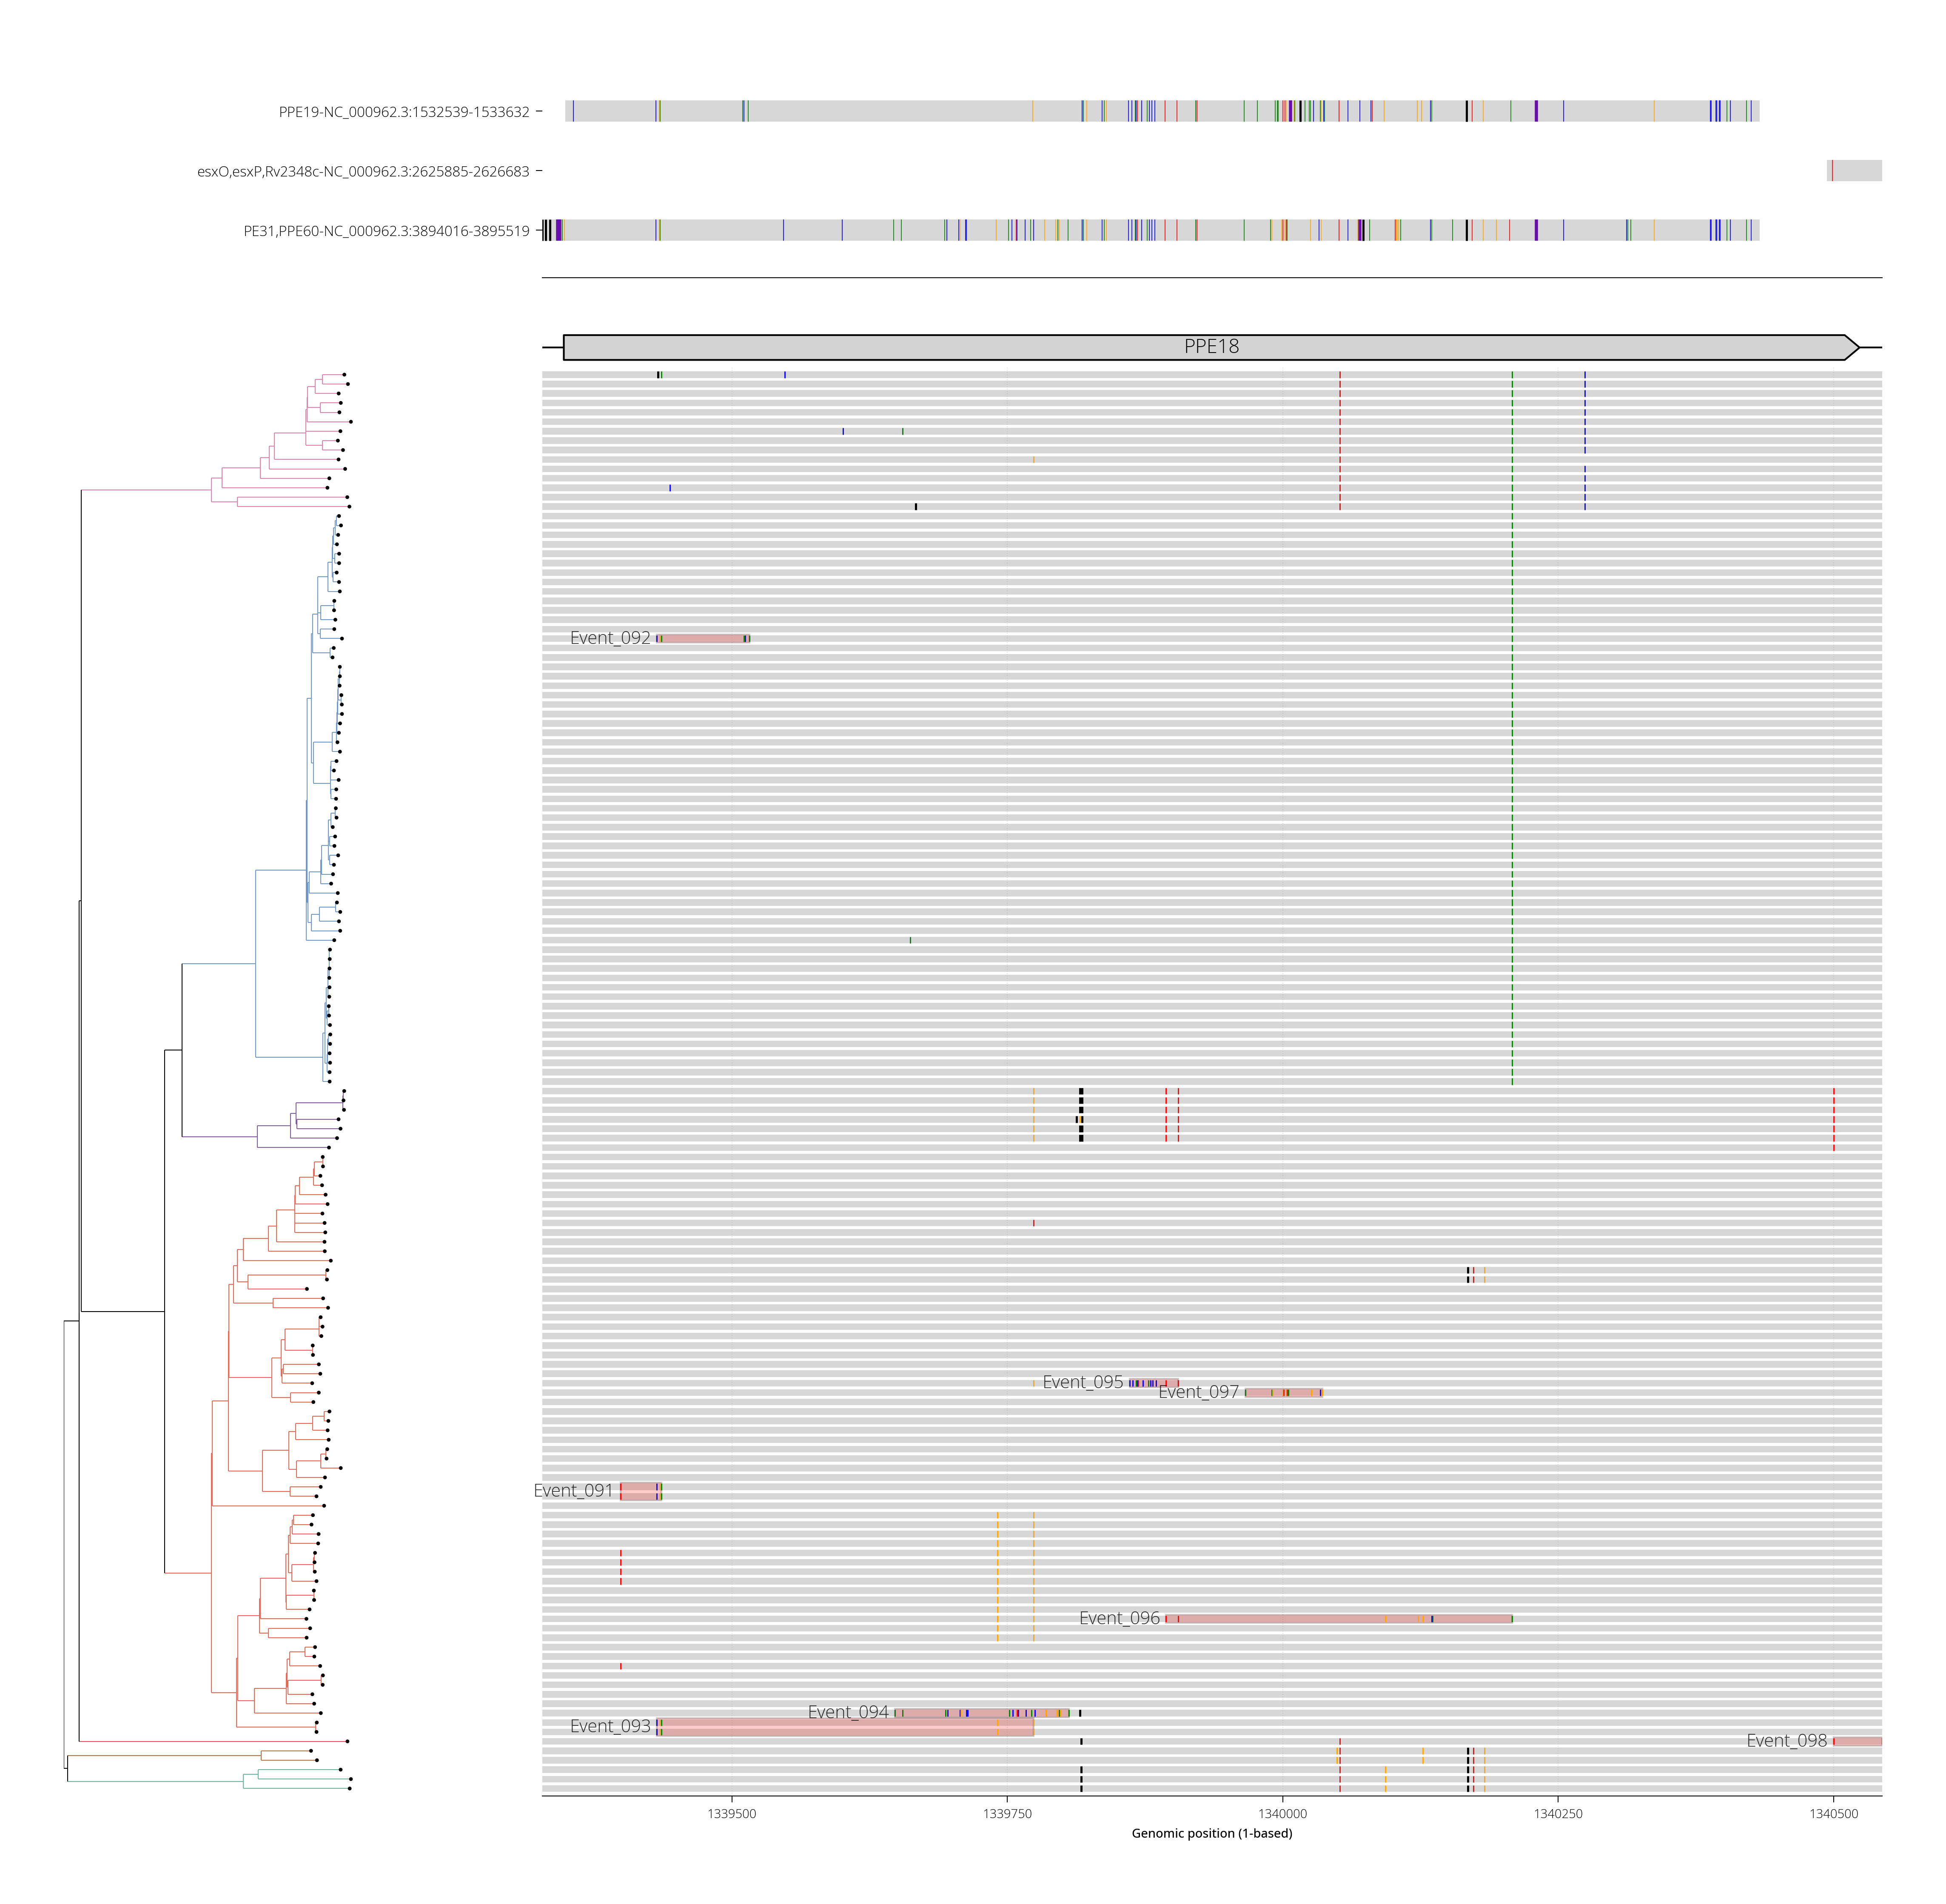

In [302]:
i_Symbol = "PPE18"

i_Gene_MutInfo_DF = H37Rv_GenomeAnno_Genes_DF.query(f"Symbol == '{i_Symbol}'")
i_Gene_Start, i_Gene_End = i_Gene_MutInfo_DF["Start"].values[0], i_Gene_MutInfo_DF["End"].values[0]
Viz_Start, Viz_End =  i_Gene_Start - 20 , i_Gene_End + 20
Viz_Coords = f"NC_000962.3:{Viz_Start}-{Viz_End}"


fig, axes, summaries = viz_region_Tree_Variants_Anno_ParalogVariants(
    Viz_Start, Viz_End,
    in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record,
    inputTree = Mtb_151CI_Tree_V1,
    i_AllVar_DF = AllAsm_AllVar_DF,
    i_GCE_DF = GCE_All_DF,       # or None
    i_ParalogVar_DF=Mtb_HM_Var_PR_DF,
    figsize = (15,14),
    tree_rect=(0.2, 0.1, 0.3, 0.8),
    paralogvariants_rect=(0.45, 0.95, 0.7, 0.12),
)

# [left_fraction, bottom_fraction, width_fraction, height_fraction]



### ii) Show events + gene anno + paralog alignments

(60402, 20) 370
(177, 20) 3
PPE19-NC_000962.3:1532539-1533632 --- 1339349 1340433 1084
esxO,esxP,Rv2348c-NC_000962.3:2625885-2626683 --- 1340494 1341292 798
PE31,PPE60-NC_000962.3:3894016-3895519 --- 1338923 1340433 1510


/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:1426: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events.loc[:, "__start1__"]     = events["start"].astype(float) + 1.0
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:1427: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events.loc[:, "__end1__"]       = events["end"].astype(float)
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomev

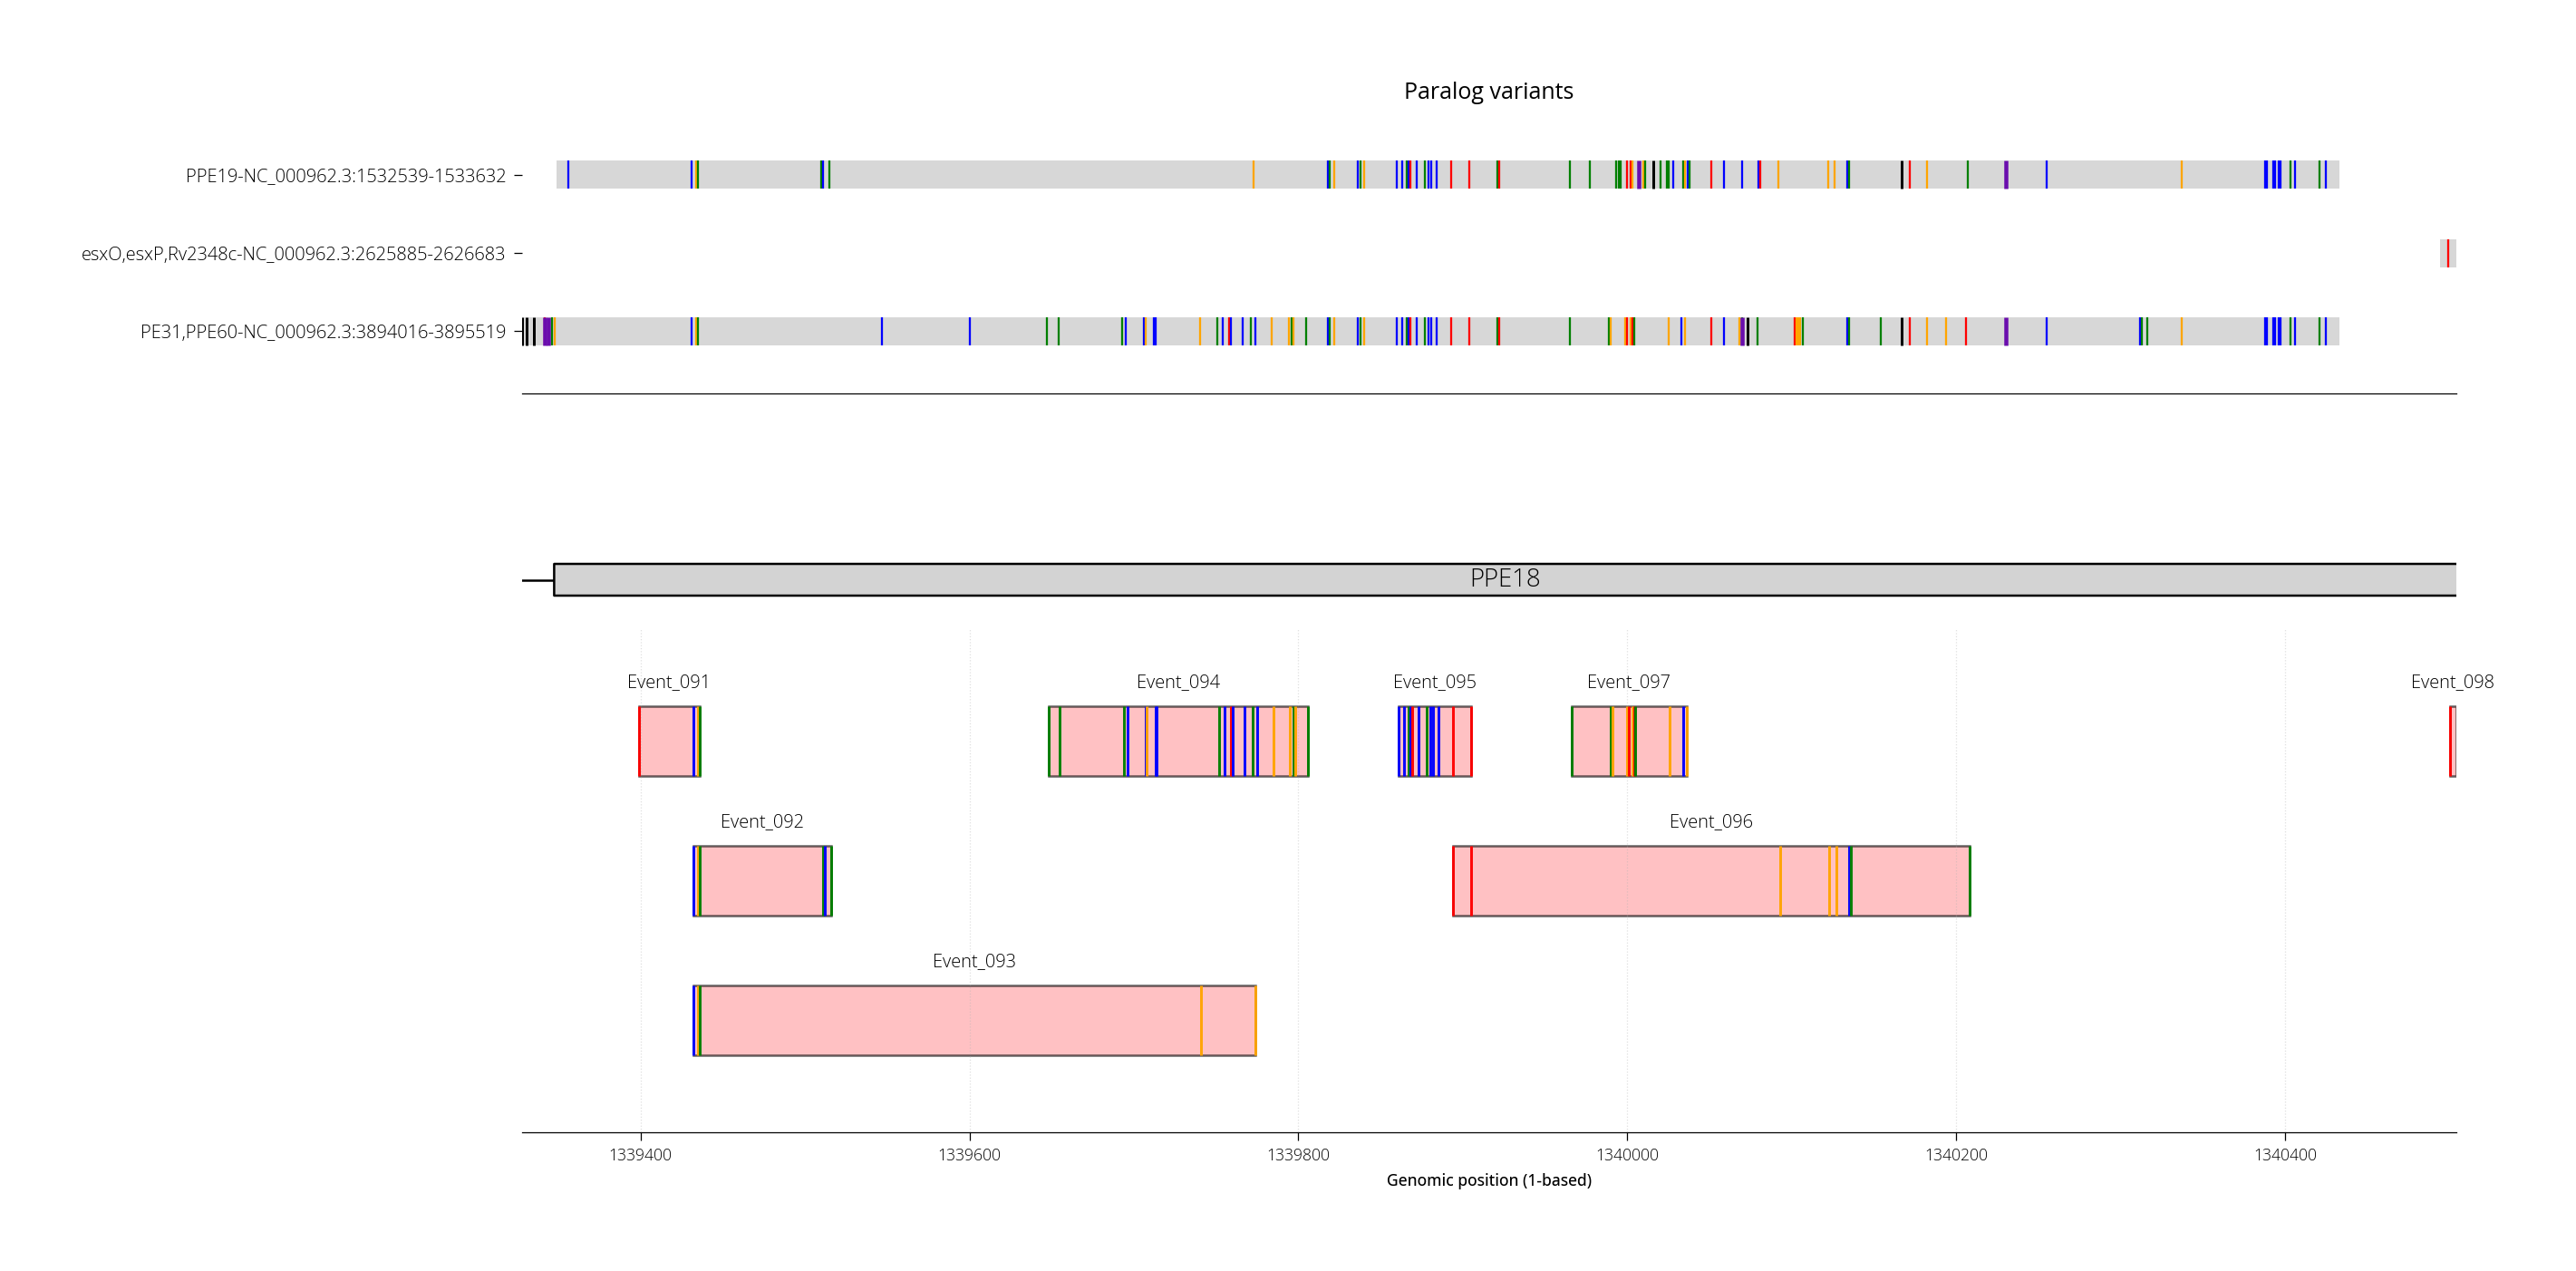

In [303]:
i_Symbol = "PPE18"

GeneInfo_DF = H37Rv_GenomeAnno_Genes_DF.query(f"Symbol == '{i_Symbol}'")
i_Gene_Start, i_Gene_End = GeneInfo_DF["Start"].values[0], GeneInfo_DF["End"].values[0]
Viz_Start, Viz_End =  i_Gene_Start - 20 , i_Gene_End - 20

fig, axes = plot_ParalogVars_Anno_with_GCE(Viz_Start, Viz_End, 
    in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record,
    pGCE_df = GCE_All_DF,
    snps_df = Gub_SNPs_V2_DF,
    ParalogVar_df = Mtb_HM_Var_PR_DF,
    GCE_color_by_CDSeffect = False,
    ShowVariant_Legend = False,
)


/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:1426: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events.loc[:, "__start1__"]     = events["start"].astype(float) + 1.0
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomeviz_utils.py:1427: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events.loc[:, "__end1__"]       = events["end"].astype(float)
/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/gcutils/genomev

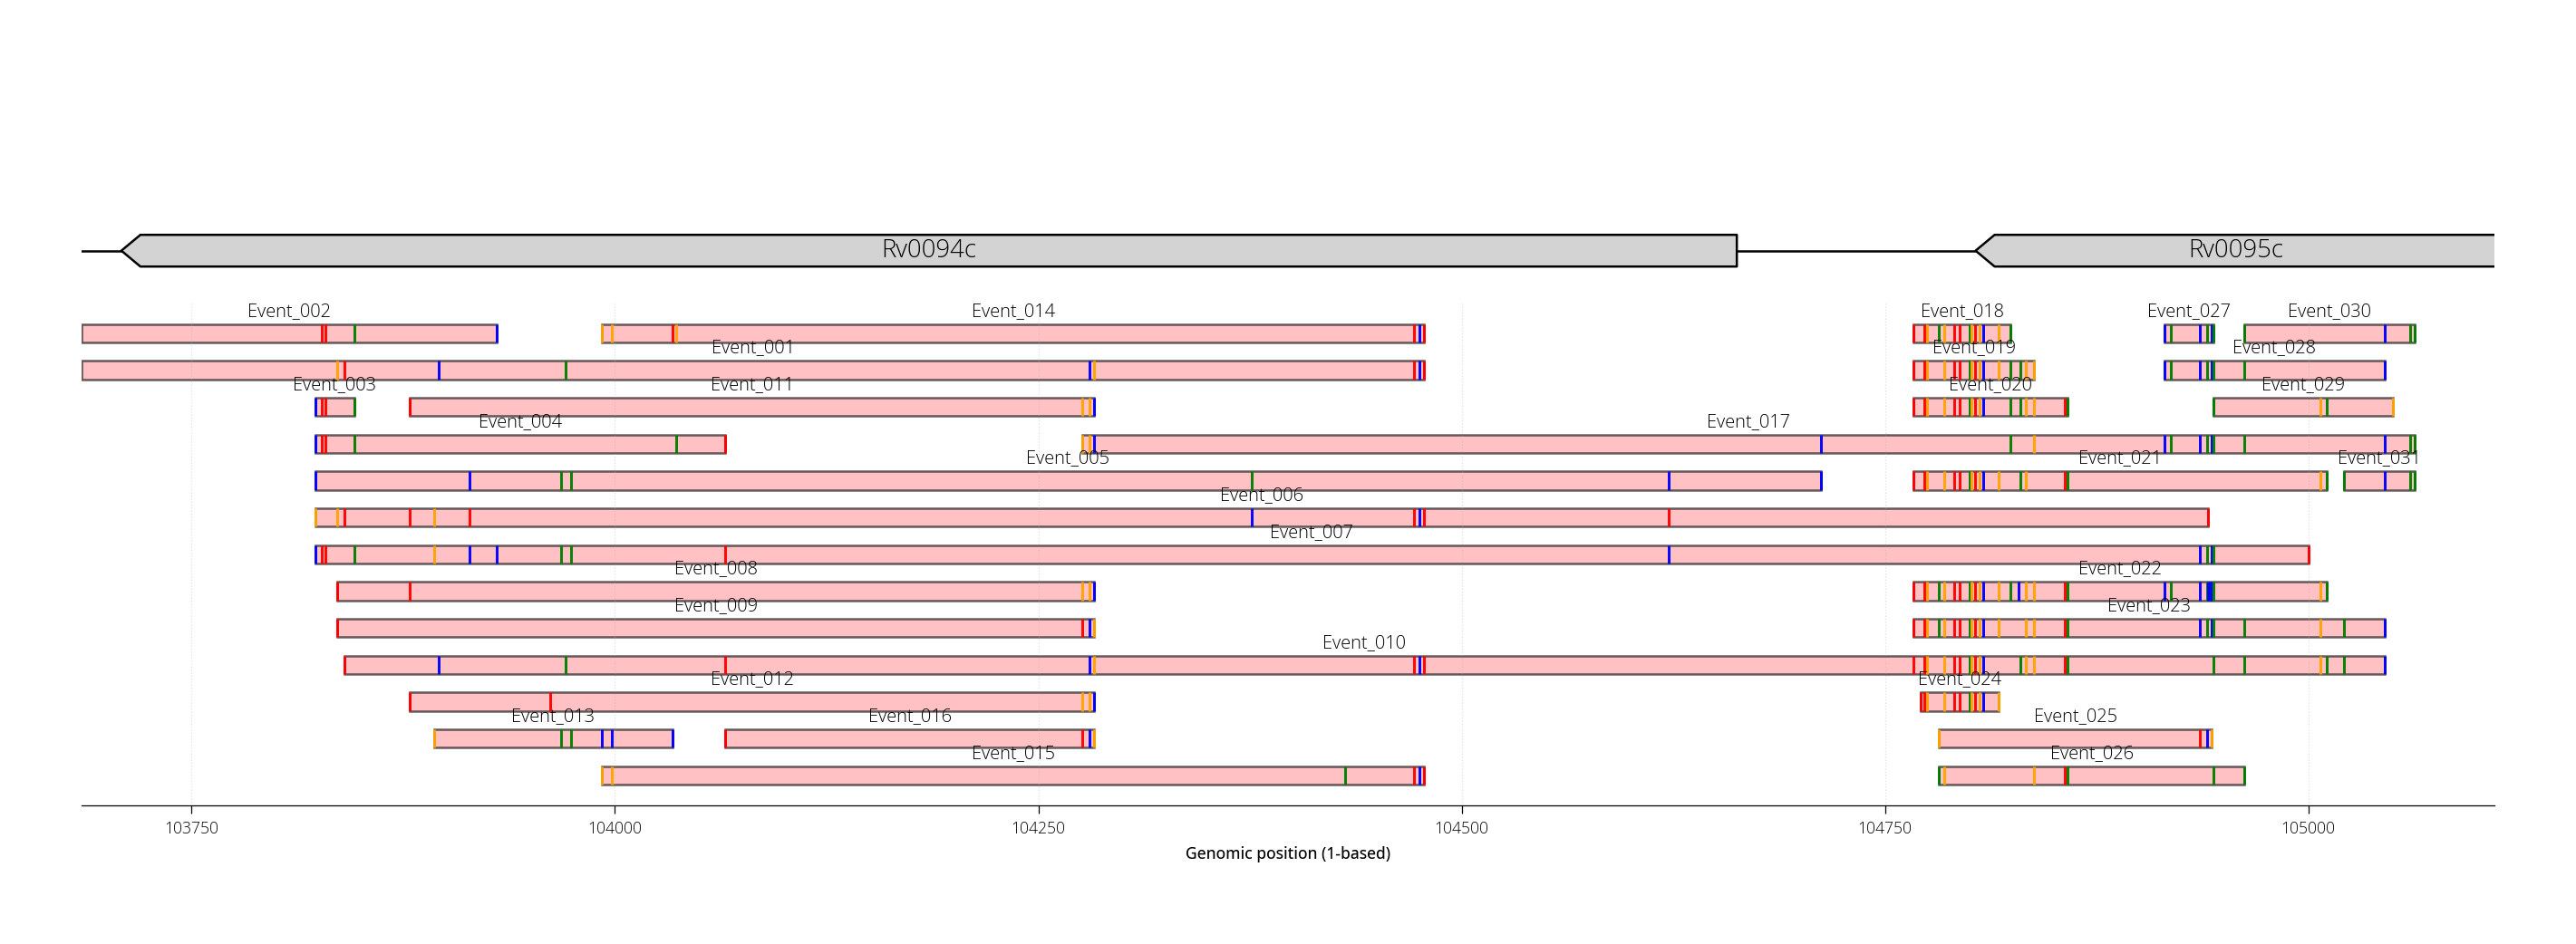

In [304]:
i_PR_ID = "PR_HmRegion_002"

i_PR_DF = PRs_WiAnyGCE_DF.query(f"HmRegionID == '{i_PR_ID}'")
i_Start, i_End = i_PR_DF["Start"].values[0], i_PR_DF["End"].values[0]
Viz_Start, Viz_End =  i_Start - 20 , i_End - 20

fig, axes = plot_Anno_with_GCE_V3(Viz_Start, Viz_End, 
    in_Genome_Graphic_Record = Mtb_H37rv_Graphic_Record,
    pGCE_df = GCE_All_DF,
    snps_df = Gub_SNPs_V2_DF,
    GCE_color_by_CDSeffect = False,
    ShowVariant_Legend = False,
)


# Extras